In [2]:
import dill
import os
import sys
import numpy as np
import pandas as pd
import pickle
from glob import glob
from tabulate import tabulate
import matplotlib.pyplot as plt


import config as cfg
import bdt_lh_cut_opt_significance
from bdt_lh_cut_opt_significance import flatten_list, plot_N, plot_interpolted_effs
import basic_functions
import bdt_lh_cut_opt_significance_exclusive_backgrounds

Welcome to JupyROOT 6.28/10


In [3]:
plotpath = 'plots/exclusive_background_studies'
samples_allocations_all = ["combined_signal", "hadronic_background","Bu2lnu_background","Bc2lnu_background"] 
samples_all = flatten_list([cfg.sample_allocations[component] for component in samples_allocations_all])

In [4]:
#Load dataframe with bdtlh version applied
data={}

for sample in samples_all:
    print(sample)
    if sample in cfg.exclusive_backgrounds:
        allocation = next((key for key, samples_list in cfg.sample_allocations.items() if sample in samples_list),None)

        if allocation is None:
            print(f"Set up needed for other exclusive backgrounds: {sample}")
            continue  # skip this sample or handle appropriately

        dir = cfg.fccana_opts["outputDir"][f"{allocation}_no_lepton_veto"]
        folder = 'dataframes_cutEVT_hemisEmin_nLept----0/bdtlh_099cut' #use samples that already have lepton veto applied

        pkl_files = glob(os.path.join(dir, folder,sample, "*.pkl"))
    
        if len(pkl_files) == 0:
            raise FileNotFoundError("No pickle files found in the folder.")

        dfs = [pd.read_pickle(f) for f in pkl_files]

        data[sample] = pd.concat(dfs, ignore_index=True)


    else:
        #inclusive backgrounds and signal samples
        dir = cfg.fccana_opts["outputDir"]["prelim_cuts_full"]
        folder = 'baseline_plus_bdtlh_dataframes/full_sample_medium_bdtlh_cut'
        data[sample] = pd.read_pickle(os.path.join(dir,folder,f'{sample}.pkl'))



# Concatenate all DataFrames
full_data = pd.concat(data.values(), ignore_index=True)


#add extra rows so can work in range0.9-1
full_data['P_signal'] = full_data['bdt_score_2']
full_data['P_not_heavy'] = 1-full_data['bdt_score_1'] 
full_data['P_not_light'] = 1-full_data['bdt_score_0'] 

#add any extra cuts need here###########################
full_data = full_data.query('EVT_hemisEmax_n>10') #veto on taus

path_for_interpolated_dicts =  'outputs/B2lnu_backgrounds_included/BDTlh_baseline_plus_cut_optimisation/no_smoothing/0995'


#read N interp dicts - 
with open(os.path.join(basic_functions.set_outputpath(path_for_interpolated_dicts), "N_remaining_dictionary"), "rb") as dill_file:
        N_dict = dill.load(dill_file)

with open(os.path.join(basic_functions.set_outputpath(path_for_interpolated_dicts), "interpolated_N_remaining_dictionary"), "rb") as dill_file:
    interp_N_dict = dill.load(dill_file)

dict_path = path_for_interpolated_dicts

#using same samples as before so that the cut points are the same
samples_for_cut_opt = cfg.sample_allocations['hadronic_background'] + cfg.sample_allocations['combined_signal']

p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu
p8_ee_Zbb_ecm91_EvtGen_Bd2NuNu
p8_ee_Zbb_ecm91
p8_ee_Zcc_ecm91
p8_ee_Zss_ecm91
p8_ee_Zud_ecm91
p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTau2MuNuNu
p8_ee_Zbb_ecm91_EvtGen_Bu2TauNuTAUHADNU
p8_ee_Zbb_ecm91_EvtGen_Bu2MuNu
p8_ee_Zbb_ecm91_EvtGen_Bc2TauNuTau2MuNuNu
p8_ee_Zbb_ecm91_EvtGen_Bc2TauNuTAUHADNU
p8_ee_Zbb_ecm91_EvtGen_Bc2MuNu


/tmp/ipykernel_2069827/975454221.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['P_signal'] = full_data['bdt_score_2']
/tmp/ipykernel_2069827/975454221.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_data['P_not_heavy'] = 1-full_data['bdt_score_1']
/tmp/ipykernel_2069827/975454221.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To

## Current baseline 20x20 in 0.995 region

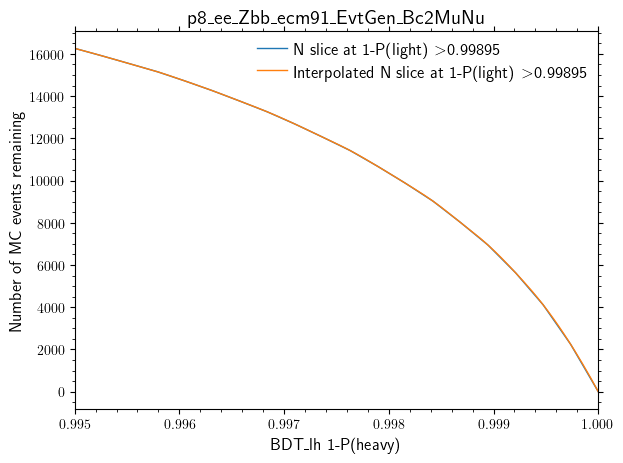

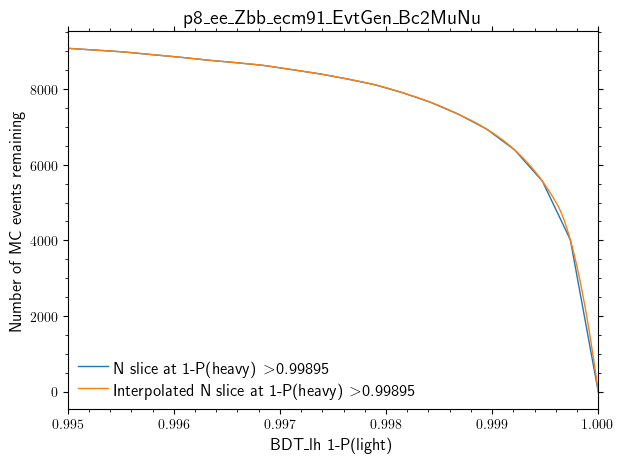

In [5]:
plot_N(N_dict, interp_N_dict, lrange=(0.995,1) ,hrange=(0.995,1),nlh_highstats=20,nlh_lowstats=20,normalised=False, separate_cbar = False,slice=True, save_path='plots/exclusive_background_studies/N_interp_0995')

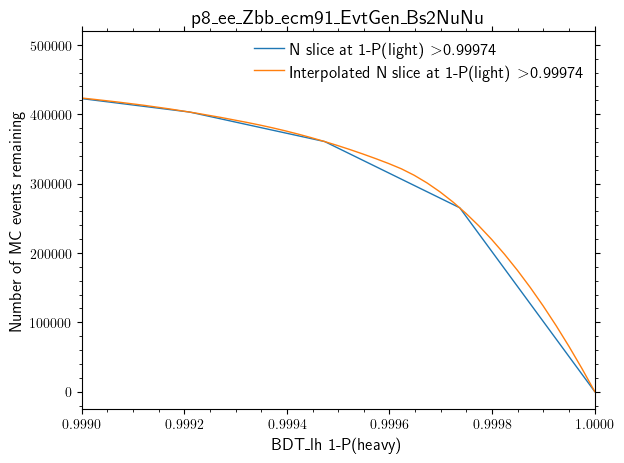

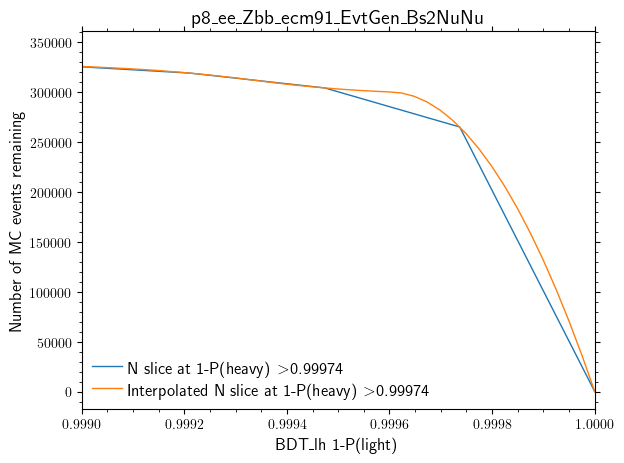

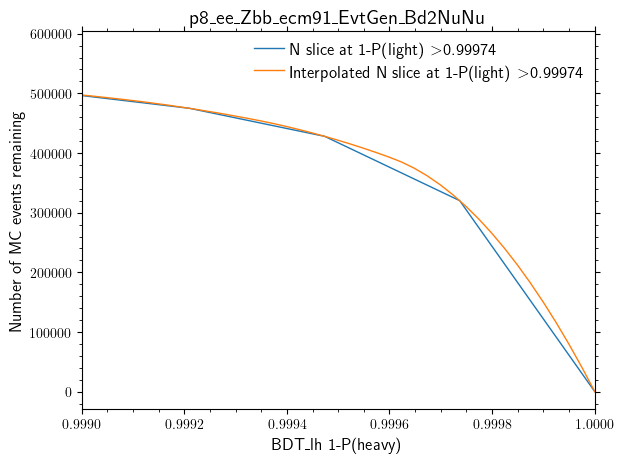

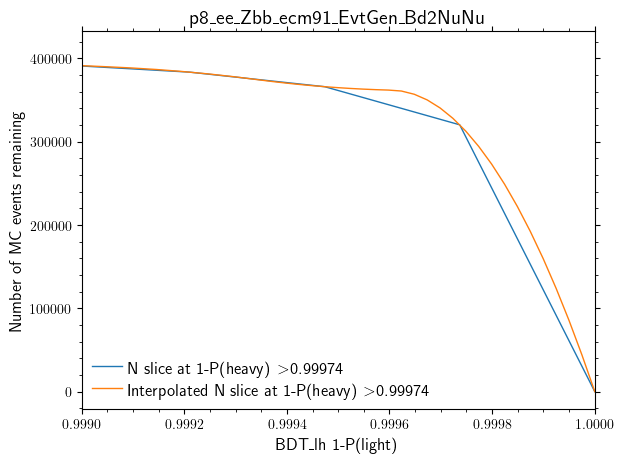

In [9]:
def plot_N_slice(N_dict, interp_N_dict, samples_allocations = ["combined_signal"], lrange=(0.995,1) ,hrange=(0.995,1),nlh=20,normalised=False, separate_cbar = False,slice=True, save_path='plots/BDTlh_baseline_plus_cut_optimisation/with_tau_veto/'):

    '''
    function to plot 2d N with and without interpolation to check smoothness as well as slices
    '''
    #define arrays want to calculate efficiency over
    lsearch = np.linspace(*lrange,nlh) 
    hsearch = np.linspace(*hrange,nlh)

    lsearchinterp = np.linspace(*lrange,nlh*10) 
    hsearchinterp = np.linspace(*hrange,nlh*10)

    samples = flatten_list([cfg.sample_allocations[component] for component in samples_allocations])
    
    i=9
    for decay in samples:

        #to remove ee
        if decay =='p8_ee_Zee_ecm91':
            continue

    
        plt.figure()
        plt.plot(hsearch,N_dict[decay][round(nlh*i/10),:], label=r'N slice at 1-P(light) $>$'+f'{round(lsearch[round(nlh*i/10)],5)}')
        N_interp_slice = [interp_N_dict[decay](lsearch[round(nlh*i/10)] , hsearchinterp[h]).item() for h in range(len(hsearchinterp))]
        plt.plot(hsearchinterp,N_interp_slice, label=r'Interpolated N slice at 1-P(light) $>$'+f'{round(lsearch[round(nlh*i/10)],5)}')
        plt.xlabel('BDT_lh 1-P(heavy)')
        plt.ylabel(r'Number of MC events remaining')
        plt.title(decay)
        plt.xlim(0.999,1)
        plt.legend()
        plt.savefig(os.path.join(basic_functions.set_outputpath(save_path),f'N_MC_events_remaining_{decay}_heavy.pdf'))


        plt.figure()
        plt.plot(lsearch,N_dict[decay][:,round(nlh*i/10)], label=r'N slice at 1-P(heavy) $>$'+f'{round(hsearch[round(nlh*i/10)],5)}')
        N_interp_slice = [interp_N_dict[decay](lsearchinterp[l], hsearch[round(nlh*i/10)]).item()  for l in range(len(lsearchinterp))]
        plt.plot(lsearchinterp,N_interp_slice, label=r'Interpolated N slice at 1-P(heavy) $>$'+f'{round(hsearch[round(nlh*i/10)],5)}')
        plt.xlabel('BDT_lh 1-P(light)')
        plt.ylabel(r'Number of MC events remaining')
        plt.legend()
        plt.xlim(0.999,1)
        plt.title(decay)
        plt.savefig(os.path.join(basic_functions.set_outputpath(save_path),f'N_MC_events_remaining_{decay}_light.pdf'))

plot_N_slice(N_dict, interp_N_dict, lrange=(0.995,1) ,hrange=(0.995,1),nlh=20,normalised=False, separate_cbar = False, save_path='plots/exclusive_background_studies/N_interp/signaltest')



## Investigating what happens when compare to more finely binned data
- I think the issue *may* be that the spline isn't finelt binned enough in the region we cut in - we cut around 0.9996 and then split into two bins in each dimension. There are only maybe 2 data points between 0.9995 and 1 used in this region....

In [10]:
from efficiency_tools.post_bdtlh_efficiency_finder import get_total_eff_post_bdt

lrange = (0.999,1)
hrange = (0.999,1)
nlh=20

lsearch = np.linspace(*lrange,nlh) 
hsearch = np.linspace(*hrange,nlh+10)


#define lists need etc


print('Creating efficiency map for decay:')

#samples = flatten_list([cfg.sample_allocations[component] for component in ["combined_signal"]])
samples = ["p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"]
    
for decay in samples:

    print(decay)

    N_df=np.zeros((len(lsearch), len(hsearch)))
    eff_df=np.zeros((len(lsearch), len(hsearch)))
    err_df=np.zeros((len(lsearch), len(hsearch)))
    
    subf = full_data[full_data["decay"]==decay]
    l_arr=[]
    h_arr=[]

    for l in np.arange(0,len(lsearch),1):
        for h in np.arange(0,len(hsearch),1):
            l_arr.append(lsearch[l])
            h_arr.append(hsearch[h])
            lh_cut = f"(P_not_heavy>{hsearch[h]})&(P_not_light>{lsearch[l]})"

            eff_lh, err_lh, N_remaining = get_total_eff_post_bdt(subf, cut= lh_cut, verbose = False, eventsProcessed_dict = cfg.eventsProcessed)
            N_df[l,h] = N_remaining[decay]
   

    N_dict[decay] = N_df


Creating efficiency map for decay:
p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu


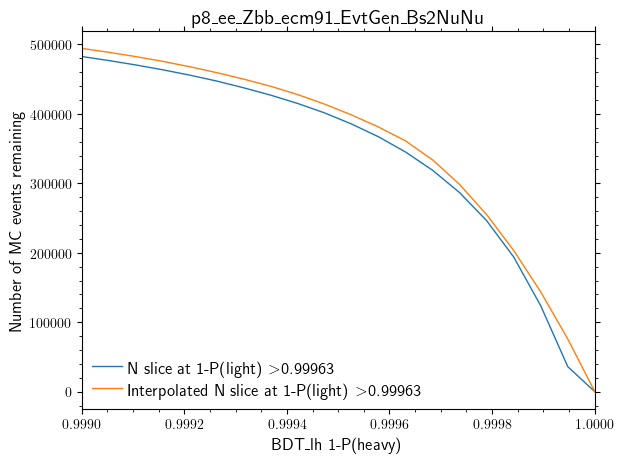

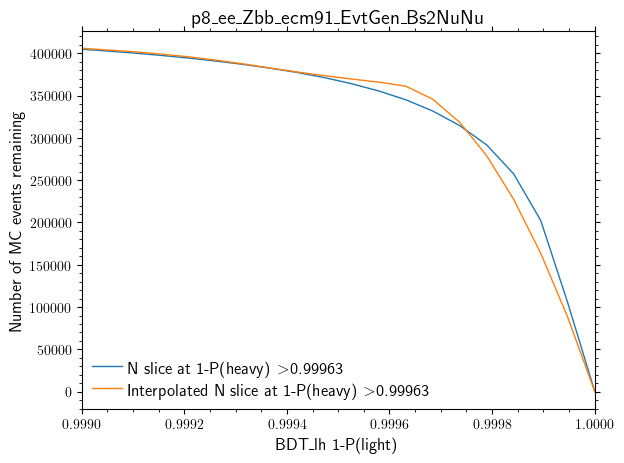

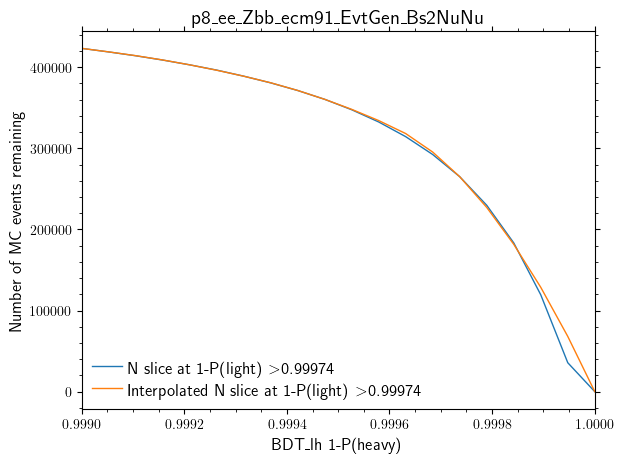

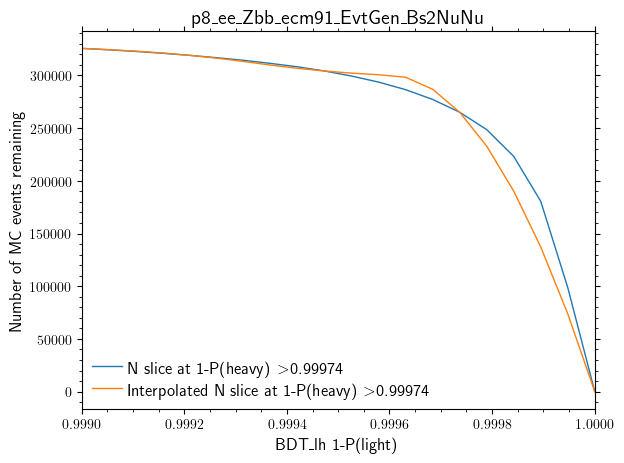

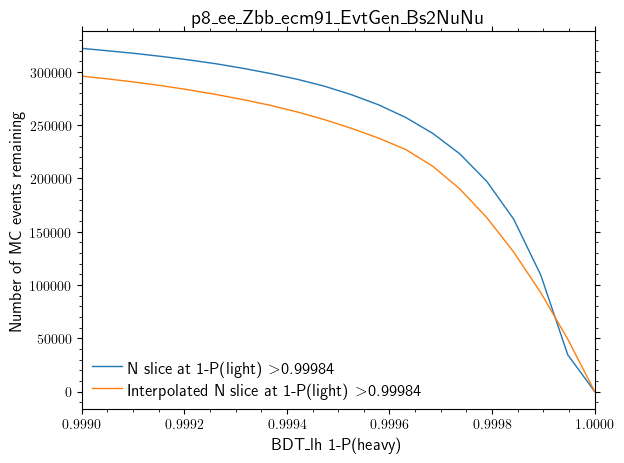

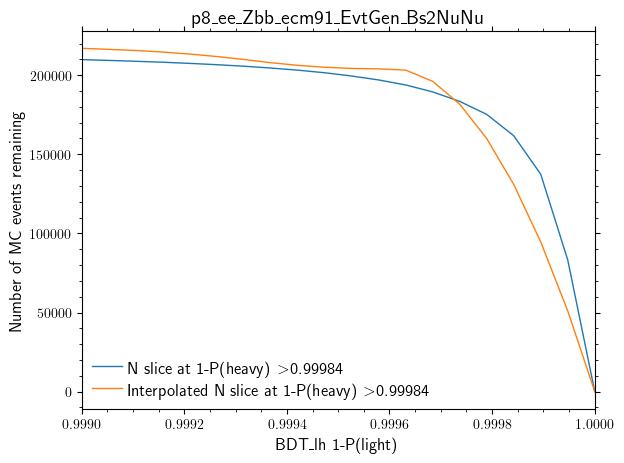

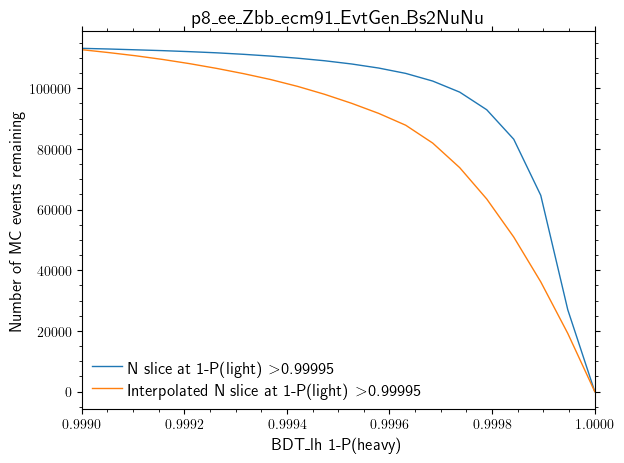

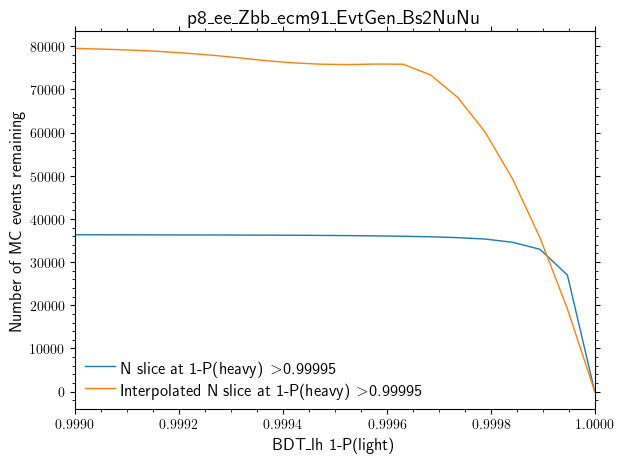

In [26]:
decay = "p8_ee_Zbb_ecm91_EvtGen_Bs2NuNu"
i_range = [6,7,8,9]

for i in i_range:
    plt.figure()
    plt.plot(hsearch,N_dict[decay][round(nlh*i/10),:], label=r'N slice at 1-P(light) $>$'+f'{round(lsearch[round(nlh*i/10)],5)}')
    N_interp_slice = [interp_N_dict[decay](lsearch[round(nlh*i/10)] , hsearch[h]).item() for h in range(len(hsearch))]
    plt.plot(hsearch,N_interp_slice, label=r'Interpolated N slice at 1-P(light) $>$'+f'{round(lsearch[round(nlh*i/10)],5)}')
    plt.xlabel('BDT_lh 1-P(heavy)')
    plt.ylabel(r'Number of MC events remaining')
    plt.title(decay)

    plt.legend()
    plt.show()

    plt.figure()


    plt.plot(lsearch,N_dict[decay][:,round(nlh*i/10)], label=r'N slice at 1-P(heavy) $>$'+f'{round(hsearch[round(nlh*i/10)],5)}')
    N_interp_slice = [interp_N_dict[decay](lsearch[l], hsearch[round(nlh*i/10)]).item()  for l in range(len(lsearch))]
    plt.plot(lsearch,N_interp_slice, label=r'Interpolated N slice at 1-P(heavy) $>$'+f'{round(hsearch[round(nlh*i/10)],5)}')
    plt.xlabel('BDT_lh 1-P(light)')
    plt.ylabel(r'Number of MC events remaining')
    plt.legend()

    plt.title(decay)
    plt.show()

In [14]:
# plot difference
N_interp_map = [interp_N_dict[decay](lsearch, hsearch, grid=True)]
#N_interp_map

In [27]:
np.array(N_interp_map)

array([[[615562.58972235, 605718.23106898, 595210.92175959,
         583652.88935382, 570979.50511169, 557190.76903313,
         542286.68111821, 526076.10846654, 507412.25367627,
         486103.98384711, 462151.29897898, 435554.19907199,
         405745.66875528, 369323.61580451, 325721.02484906,
         274937.89588874, 216974.22892378, 151830.02395391,
          79505.28097942,      0.        ],
        [610092.67285187, 600447.46068109, 590148.49892365,
         578811.27919121, 566371.71675244, 552829.81160728,
         538185.56375578, 522250.09451685, 503890.13180423,
         482916.79693693, 459330.08991485, 433130.0107381 ,
         403741.23505209, 367711.81673013, 324466.43141784,
         274005.07911505, 216327.75982196, 151434.47353834,
          79325.22026445,      0.        ],
        [604185.57084105, 594751.95912226, 584674.52693913,
         573572.47327326, 561382.3312883 , 548104.10098419,
         533737.78236099, 518096.94398769, 500062.99727865,
         479

In [28]:
np.array(N_dict[decay])

array([[615449., 605536., 594990., 583433., 570823., 557078., 541734.,
        525108., 506702., 485997., 462404., 435564., 404735., 368638.,
        325705., 273926., 209847., 129052.,  36339.,      0.],
       [609875., 600150., 589812., 578479., 566114., 552600., 537501.,
        521173., 503057., 482690., 459406., 432931., 402445., 366758.,
        324311., 272991., 209341., 128920.,  36325.,      0.],
       [603825., 594314., 584189., 573078., 560965., 547726., 532908.,
        516886., 499100., 479071., 456169., 430089., 400013., 364755.,
        322794., 271977., 208799., 128761.,  36317.,      0.],
       [597197., 587896., 577991., 567128., 555293., 542319., 527777.,
        512080., 494642., 474991., 452451., 426830., 397237., 362469.,
        321061., 270806., 208197., 128576.,  36304.,      0.],
       [589752., 580690., 571029., 560463., 548942., 536288., 522112.,
        506756., 489716., 470498., 448386., 423234., 394116., 359902.,
        319071., 269449., 207465., 128

/tmp/ipykernel_1371079/3765880108.py:1: RuntimeWarning: invalid value encountered in divide
  plt.imshow(np.squeeze(np.array(N_interp_map) - np.array(N_dict[decay]))/np.array(N_dict[decay]),  origin="lower", extent=[hrange[0],hrange[1],lrange[0],lrange[1]]) #not squeeze just removes an extra set of braces


Text(0, 0.5, '1-P(l)')

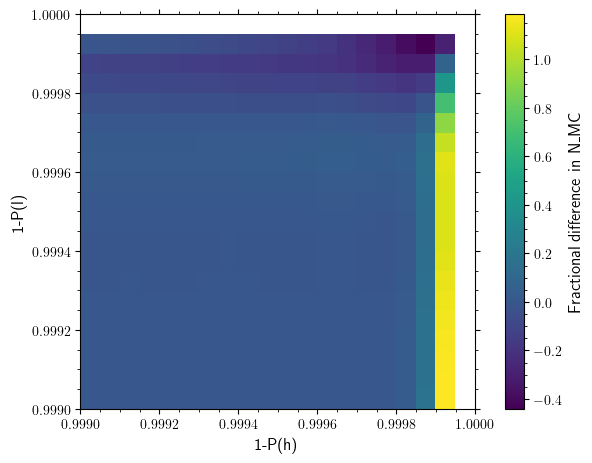

In [15]:
plt.imshow(np.squeeze(np.array(N_interp_map) - np.array(N_dict[decay]))/np.array(N_dict[decay]),  origin="lower", extent=[hrange[0],hrange[1],lrange[0],lrange[1]]) #not squeeze just removes an extra set of braces
plt.colorbar(label='Fractional difference in N_MC')
plt.xlabel("1-P(h)")
plt.ylabel("1-P(l)")

In [35]:
arr = np.squeeze(np.array(N_interp_map) - np.array(N_dict[decay]))/np.array(N_dict[decay])
print(lsearch[13])
print(lsearch[16])
print(arr[13,13])
print(arr[13,16])
print(arr[16,13])
print(arr[16,16])


0.9996842105263158
0.9998421052631579
0.042406698040005
0.03521425495132749
-0.12717412618547907
-0.19047964426364283


/tmp/ipykernel_1371079/141843056.py:1: RuntimeWarning: invalid value encountered in divide
  arr = np.squeeze(np.array(N_interp_map) - np.array(N_dict[decay]))/np.array(N_dict[decay])


In [1]:
plt.imshow(np.squeeze(np.array(N_interp_map) - np.array(N_dict[decay])),  origin="lower", extent=[hrange[0],hrange[1],lrange[0],lrange[1]]) #not squeeze just removes an extra set of braces
plt.colorbar(label='Absolute difference in N_MC')
plt.xlabel("1-P(h)")
plt.ylabel("1-P(l)")
plt.show()

arr_abs = np.squeeze(np.array(N_interp_map) - np.array(N_dict[decay]))/np.array(N_dict[decay])

print(arr_abs[13,13])
print(arr_abs[13,16])
print(arr_abs[16,13])
print(arr_abs[16,16])

NameError: name 'plt' is not defined

## See if creating new N_interp_maps_helps

/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/bdt_lh_cut_opt_significance.py:236: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


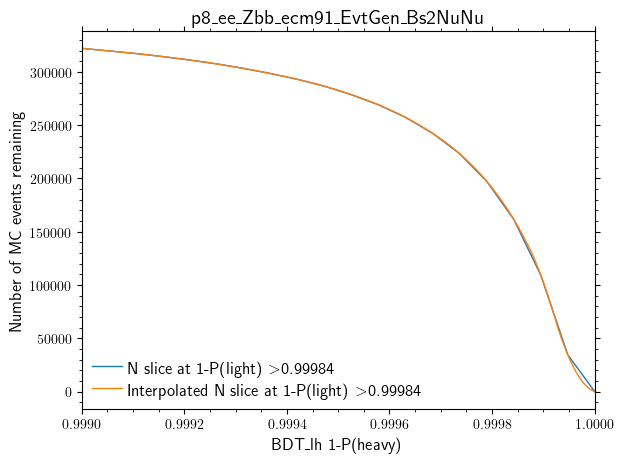

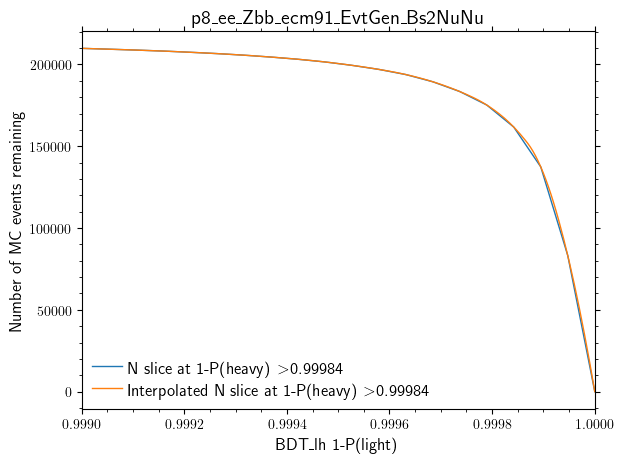

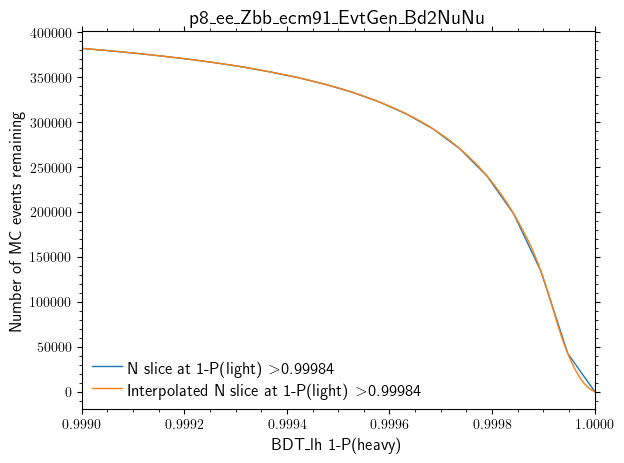

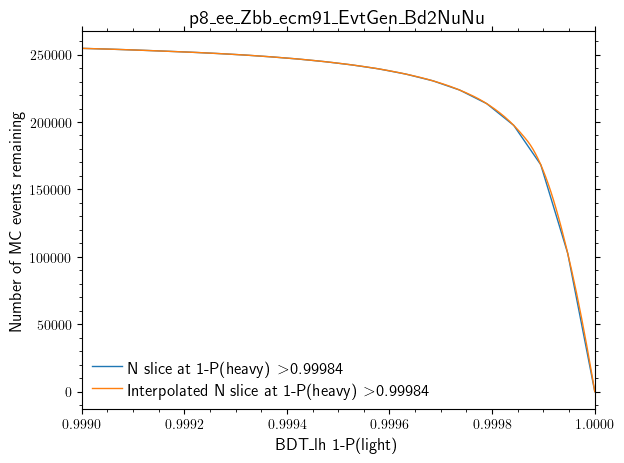

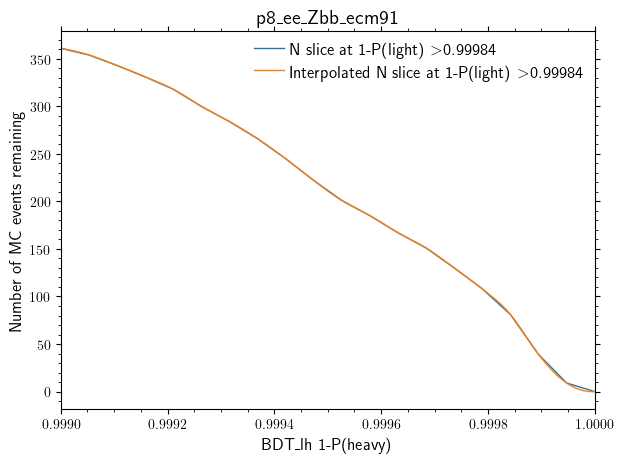

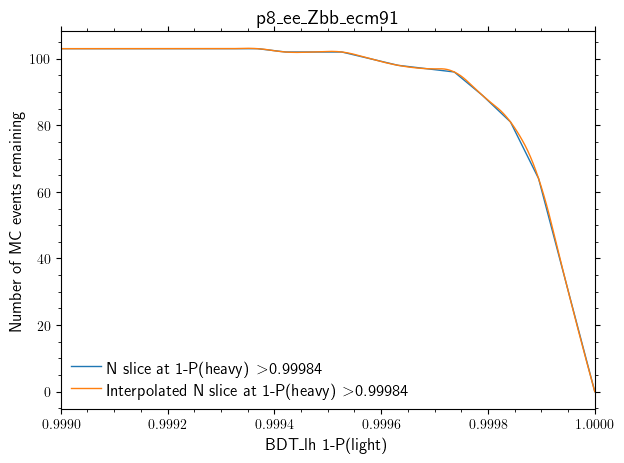

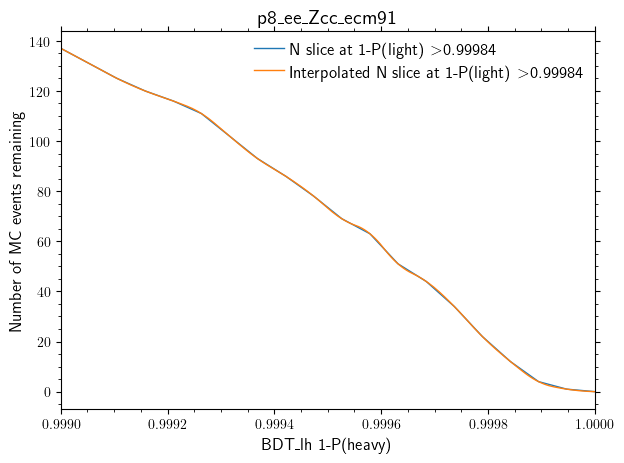

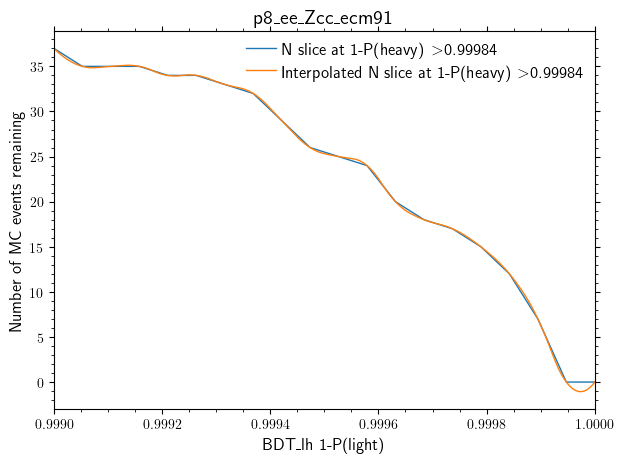

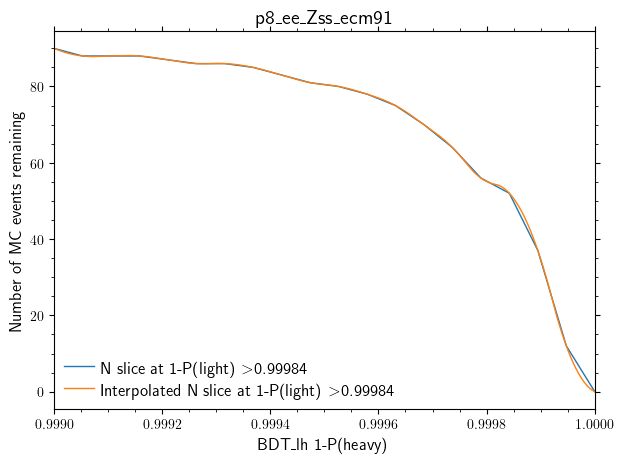

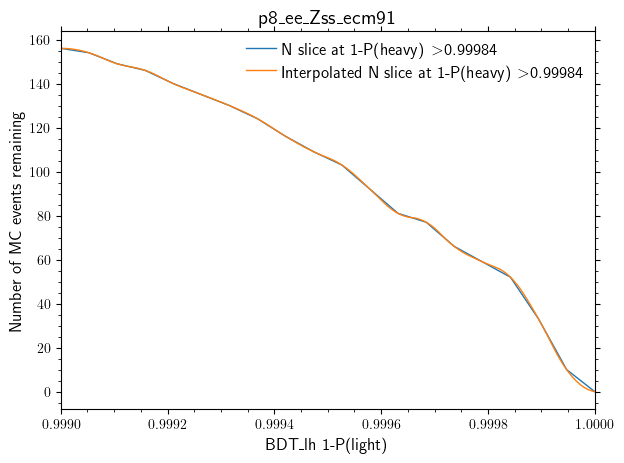

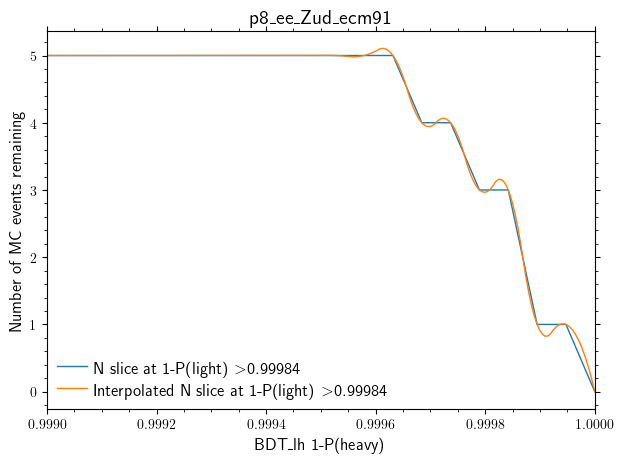

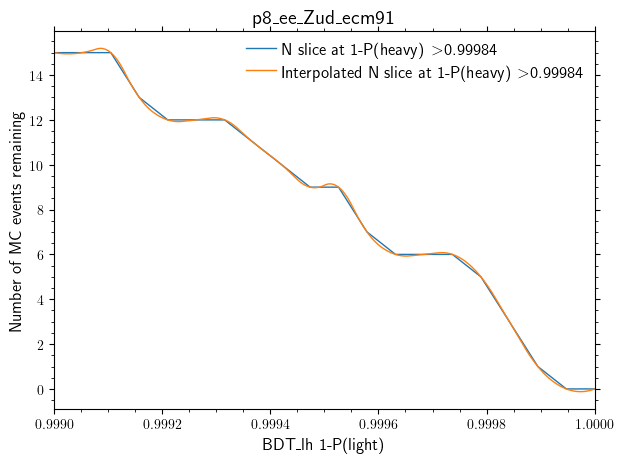

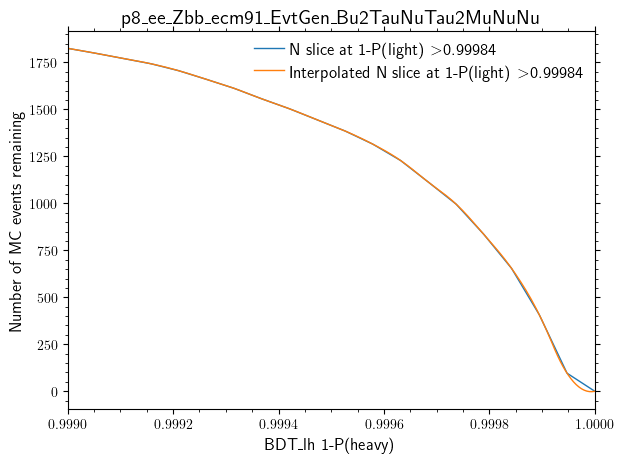

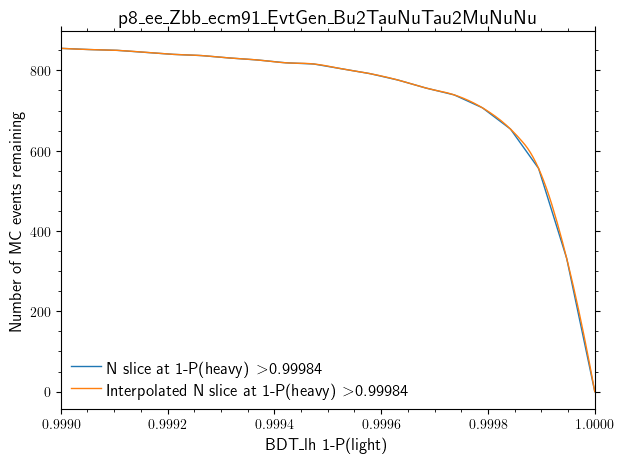

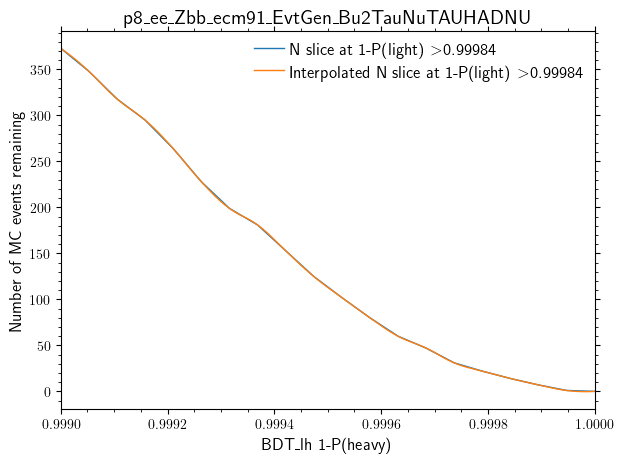

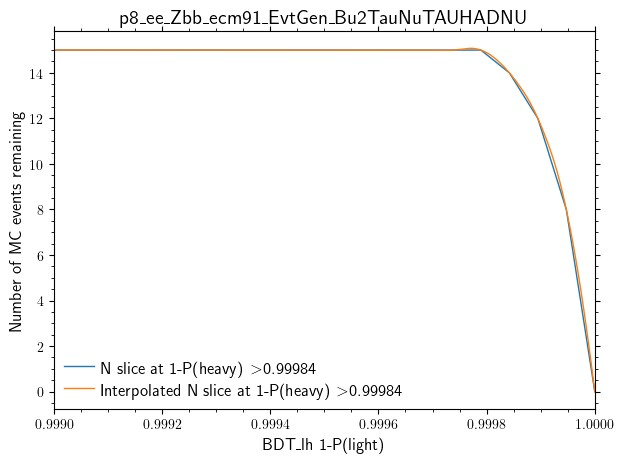

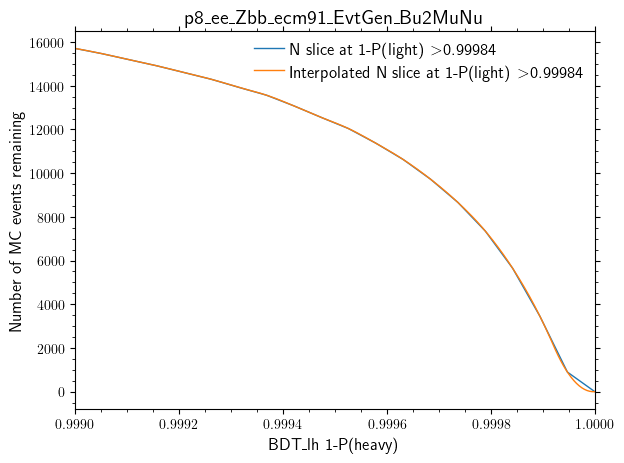

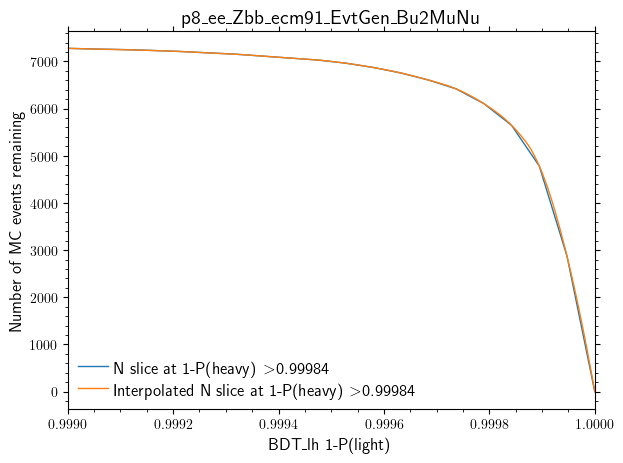

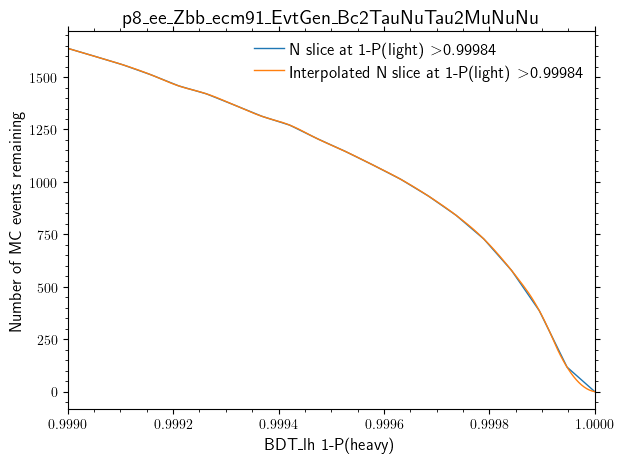

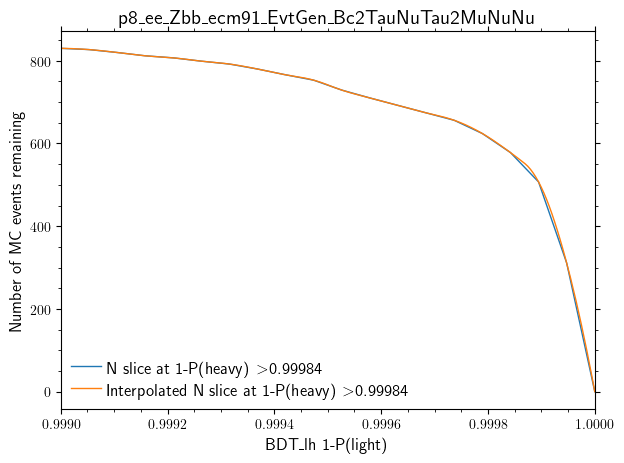

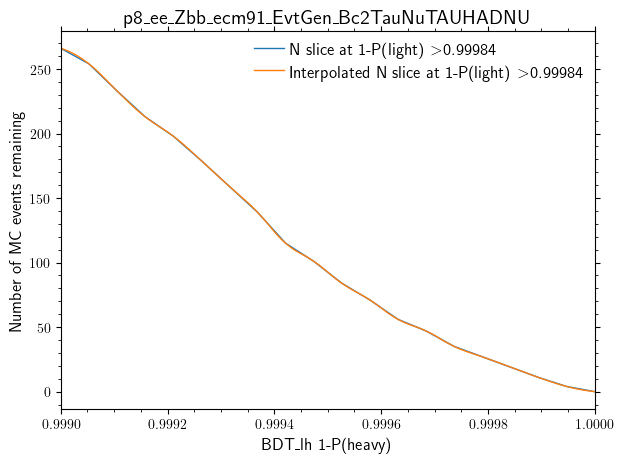

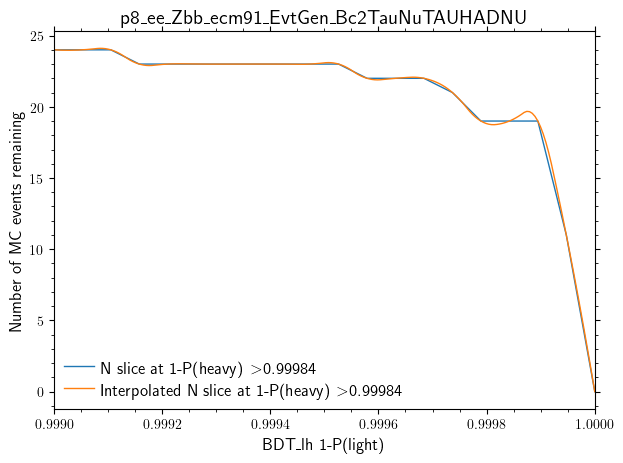

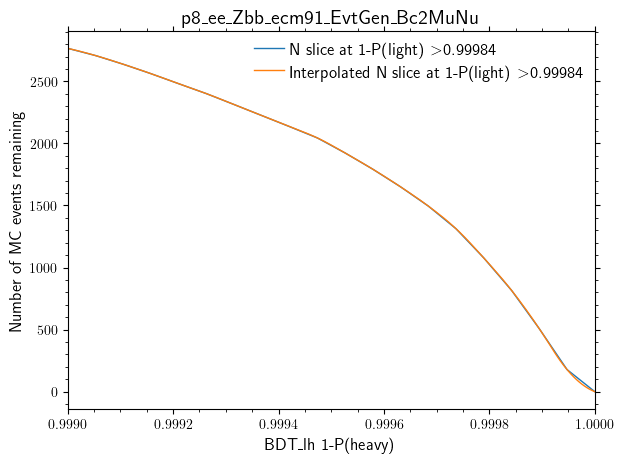

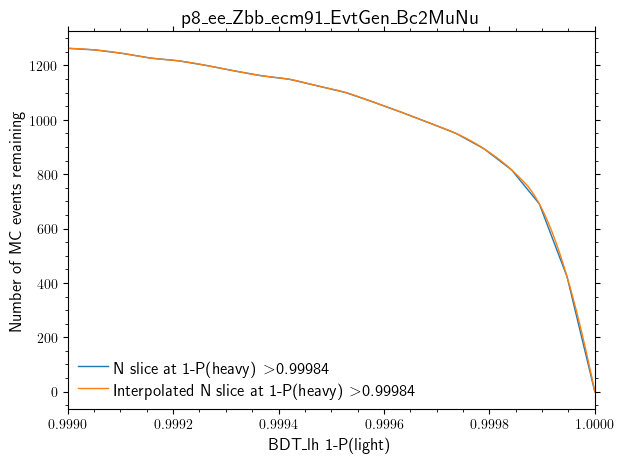

In [4]:
path_for_interpolated_dicts_0999 =  'outputs/B2lnu_backgrounds_included/BDTlh_baseline_plus_cut_optimisation/no_smoothing/0999/test'

#read N interp dicts - 
with open(os.path.join(basic_functions.set_outputpath(path_for_interpolated_dicts_0999), "N_remaining_dictionary"), "rb") as dill_file:
        N_dict_0999 = dill.load(dill_file)

with open(os.path.join(basic_functions.set_outputpath(path_for_interpolated_dicts_0999), "interpolated_N_remaining_dictionary"), "rb") as dill_file:
    interp_N_dict_0999 = dill.load(dill_file)

plot_N(N_dict_0999, interp_N_dict_0999, lrange=(0.999,1) ,hrange=(0.999,1),nlh=20,normalised=False, separate_cbar = False,slice=True, save_path='plots/exclusive_background_studies/N_interp_0999/test')

In [5]:
from bdt_lh_cut_opt_significance import run_2d_optimisation, calc_SB_from_opt_cut # note that this has been updated to allow cut_opt_samples input (ie. tell it which samples to run optimisation on)
import matplotlib.pyplot as plt

samples_for_cut_opt = cfg.sample_allocations['hadronic_background'] + cfg.sample_allocations['combined_signal']
cut_opt_samples=samples_for_cut_opt 
lrange_interp_N_dict_0999=(0.999,1)
hrange_interp_N_dict_0999=(0.999,1)
nlh = 200 
signal_BF=1e-6
eventsProcessed_dict = cfg.eventsProcessed
histbins=(2,2)
components_to_plot =  ['hadronic_background','combined_signal']
binned_x_axis = np.array([['Signal depleted','Heavy background \n enriched'],['Light background \n enriched','Signal enriched']])


FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = run_2d_optimisation(interp_N_dict_0999, cut_opt_samples=cut_opt_samples, lrange_plot=lrange_interp_N_dict_0999 ,hrange_plot=hrange_interp_N_dict_0999, nlh=nlh , sig_BF=signal_BF, incl_other_syst = False)

indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]


# define samples want from components input 
samples = flatten_list([cfg.sample_allocations[component] for component in components_to_plot])


# Number of events per bin in MC from interpolation 

if histbins != (2,2):
    raise ValueError("Currently only set up for histbins=(2,2)")

else:   
    #bin edges - h on x axis, l on y axis
    h_bins_edges = np.linspace(h_cut, 1, histbins[0] + 1) #x axis
    l_bins_edges = np.linspace(l_cut, 1, histbins[1] + 1)

    
    N_dict_MC_0999 = {}

    print('--> Finding number of events per bin')
    #find number of MC events per bin after interpolation
    for sample in interp_N_dict_0999.keys():
        # Grid shape: (histbins[0]+1, histbins[1]+1)
        F = np.zeros((histbins[0] + 1, histbins[1] + 1))

        for ih in range(histbins[0] + 1):
            for il in range(histbins[1] + 1):
                F[ih, il] = interp_N_dict_0999[sample](l_bins_edges[il], h_bins_edges[ih], grid=False)
            # number of events with H > h_cut and L > l_cut
        
        #print(F)
        #print(F[0, 1] )
        #print(F[0, 2] )
        #print(F[1, 1] )
        #print(F[1, 2] )
        
        N_MC = np.zeros((histbins[0], histbins[1]))
        
        for ih in range(histbins[0]):
            for il in range(histbins[1]):

                # finite difference
                N_MC[ih, il] = (
                    F[ih, il]     # bottom-left corner
                    - F[ih+1, il]     # bottom-right
                    - F[ih,   il+1]   # top-left
                    + F[ih+1, il+1]   # top-right (restore overlap)
                    )

    
        N_dict_MC_0999[sample] =  N_MC

        '''
        
        # Create a figure
        plt.figure(figsize=(8,6))


        # N_MC should match the "grid" of bin edges, so h_bins_edges on x, l_bins_edges on y
        # pcolormesh expects shape (len(y_edges)-1, len(x_edges)-1), so may need to transpose
        plt.pcolormesh(h_bins_edges, l_bins_edges, N_MC.T, shading='auto', cmap=plt.cm.Blues, vmin=0)

        plt.colorbar(label='Number of MC events')
        plt.xlabel('$1-P(h)$')
        plt.ylabel('$1-P(l)$')
        plt.title(cfg.titles[sample])

        plt.show()
        '''
        


Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       157.444 |             0.999648 |             0.999623 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin


Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       157.444 |             0.999648 |             0.999623 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin
[[ 40.45427016  17.5490062 ]
 [ 76.99923685 102.14599644]]
[[ 37.  18.]
 [ 77. 103.]]
[[ 9.33586529e-02 -9.91101893e-06]
 [-2.50552109e-02 -8.29129673e-03]]


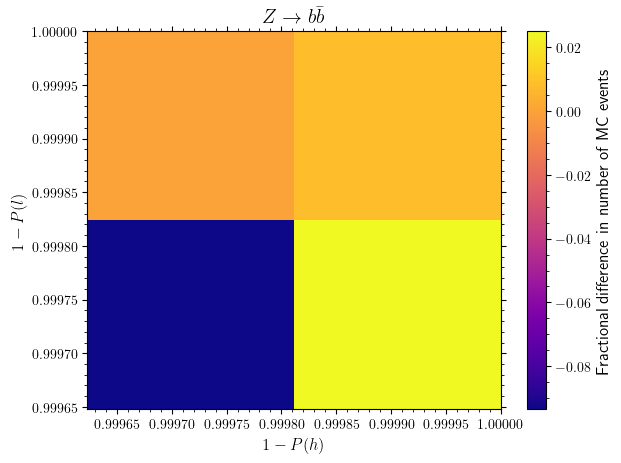

[[36.66997713  8.96347582]
 [41.50753776 19.49725845]]
[[37.  9.]
 [35. 22.]]
[[-0.00891954  0.18592965]
 [-0.00405824 -0.11376098]]


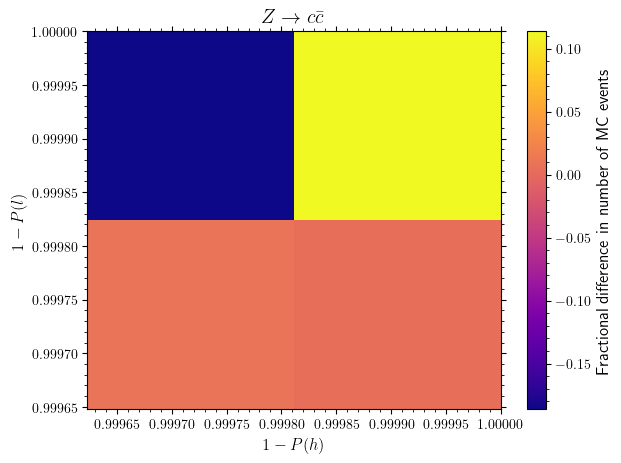

[[40.32528891 31.70716347]
 [24.05804229 58.7895508 ]]
[[35. 36.]
 [23. 58.]]
[[ 0.15215111  0.04600184]
 [-0.11924546  0.01361294]]


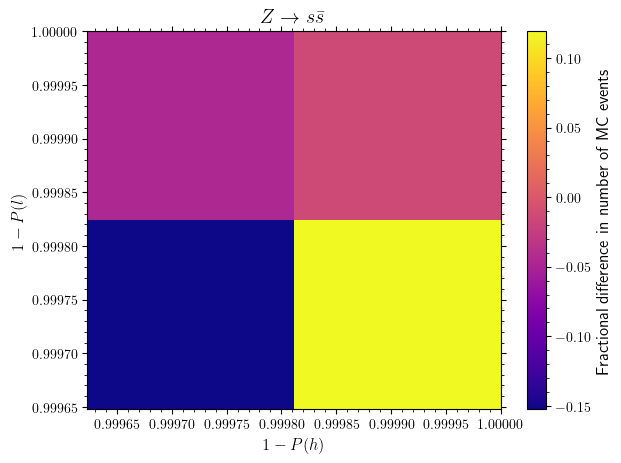

[[6.10661233 4.18408355]
 [2.5970057  3.92646972]]
[[5. 6.]
 [3. 3.]]
[[ 0.22132247 -0.13433143]
 [-0.30265274  0.30882324]]


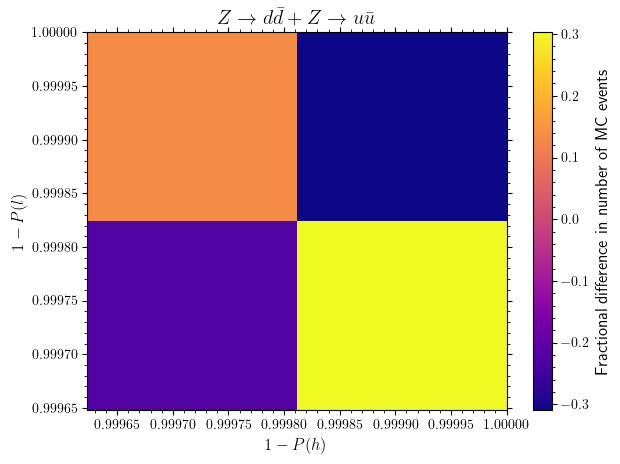

[[ 38446.68284354  33454.98147193]
 [ 82248.82772481 190715.86940219]]
[[ 38676.  33420.]
 [ 82204. 190623.]]
[[-0.00592918  0.00054532]
 [ 0.00104672  0.00048719]]


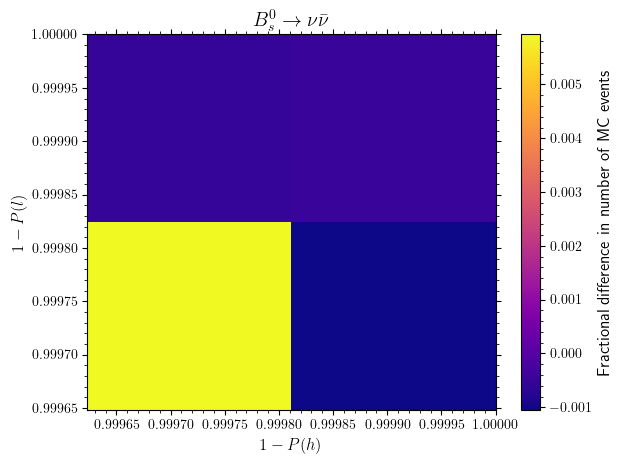

[[ 44813.37994884  39656.05097633]
 [ 95078.88946821 232162.31529636]]
[[ 44805.  39710.]
 [ 95055. 232245.]]
[[ 0.00018703  0.00025132]
 [-0.00135858 -0.00035602]]


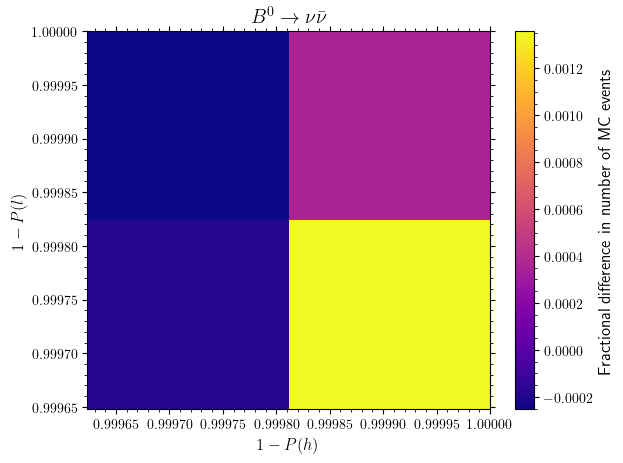

---
[0.99962312 0.99981156 1.        ]
[0.99962312 0.99981156 1.        ]
---
[0.99964824 0.99982412 1.        ]
[0.99964824 0.99982412 1.        ]
---


In [7]:
# GET HISTOGRAMS FOR DATA   
df = full_data

# find optimum cut
FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = run_2d_optimisation(interp_N_dict_0999, cut_opt_samples=cut_opt_samples, lrange_plot=lrange_interp_N_dict_0999 ,hrange_plot=hrange_interp_N_dict_0999, nlh=nlh , sig_BF=signal_BF, incl_other_syst = False)

indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]

#cut df on optimal BDT cuts
cut_data = df.copy().query(f'(P_not_light>{l_cut})&(P_not_heavy>{h_cut})')

# define samples want from components input 
samples = flatten_list([cfg.sample_allocations[component] for component in components_to_plot])

print('--> Finding number of events per bin')
# get number of events per bin in MC using np.2d histogram
#N_dict_MC={}


for decay in samples:
    
    plt.figure()
    h=plt.hist2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=histbins, cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
    plt.pcolormesh(h_bins_edges, l_bins_edges, (h[0].T-N_dict_MC_0999[decay].T)/(h[0].T), shading='auto', cmap='plasma')
    plt.colorbar(label='Fractional difference in number of MC events')
    plt.xlabel('$1-P(h)$')
    plt.ylabel('$1-P(l)$')
    plt.title(cfg.titles[decay])
    print(N_dict_MC_0999[decay].T)
    print(h[0].T)
    print((N_dict_MC_0999[decay]-h[0])/(h[0]))
    plt.show()


print("---") 
print(h_bins_edges)
print(h[1])
print("---") 
print(l_bins_edges)
print(h[2])
print("---")


## New Splines - 4x4 for low stats and 20x20 for high stats

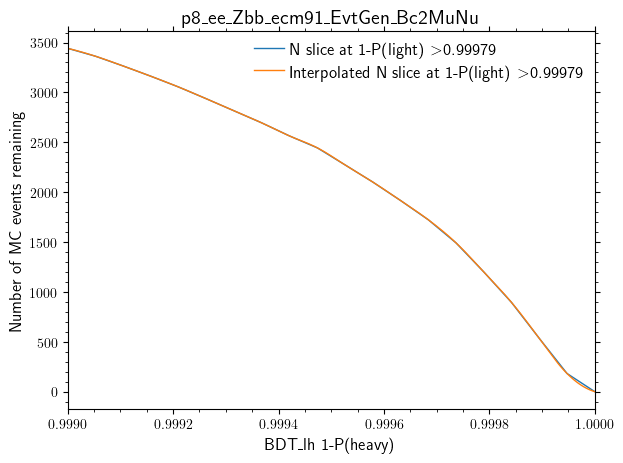

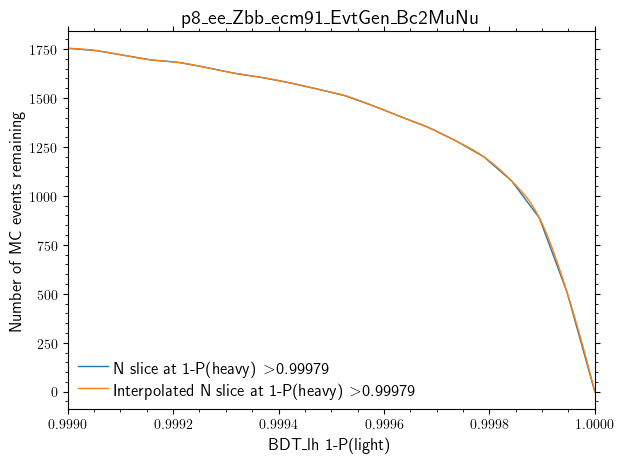

In [4]:
path_for_interpolated_dicts_0999 =  'outputs/B2lnu_backgrounds_included/BDTlh_baseline_plus_cut_optimisation/no_smoothing/0999/4x4lowstats'

#read N interp dicts - 
with open(os.path.join(basic_functions.set_outputpath(path_for_interpolated_dicts_0999), "N_remaining_dictionary"), "rb") as dill_file:
        N_dict_0999 = dill.load(dill_file)

with open(os.path.join(basic_functions.set_outputpath(path_for_interpolated_dicts_0999), "interpolated_N_remaining_dictionary"), "rb") as dill_file:
    interp_N_dict_0999 = dill.load(dill_file)

plot_N(N_dict_0999, interp_N_dict_0999, lrange=(0.999,1) ,hrange=(0.999,1),nlh_highstats=20,nlh_midstats=4,nlh_lowstats=4,normalised=False, separate_cbar = False,slice=True, save_path='plots/exclusive_background_studies/N_interp_0999/4x4lowstats')

In [5]:
from bdt_lh_cut_opt_significance import run_2d_optimisation, calc_SB_from_opt_cut # note that this has been updated to allow cut_opt_samples input (ie. tell it which samples to run optimisation on)
import matplotlib.pyplot as plt

samples_for_cut_opt = cfg.sample_allocations['hadronic_background'] + cfg.sample_allocations['combined_signal']
cut_opt_samples=samples_for_cut_opt 
lrange_interp_N_dict_0999=(0.999,1)
hrange_interp_N_dict_0999=(0.999,1)
nlh = 200 
signal_BF=1e-6
eventsProcessed_dict = cfg.eventsProcessed
histbins=(2,2)
components_to_plot =  ['hadronic_background','combined_signal']
binned_x_axis = np.array([['Signal depleted','Heavy background \n enriched'],['Light background \n enriched','Signal enriched']])


FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = run_2d_optimisation(interp_N_dict_0999, cut_opt_samples=cut_opt_samples, lrange_plot=lrange_interp_N_dict_0999 ,hrange_plot=hrange_interp_N_dict_0999, nlh=nlh , sig_BF=signal_BF, incl_other_syst = False)

indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]


# define samples want from components input 
samples = flatten_list([cfg.sample_allocations[component] for component in components_to_plot])


# Number of events per bin in MC from interpolation 

if histbins != (2,2):
    raise ValueError("Currently only set up for histbins=(2,2)")

else:   
    #bin edges - h on x axis, l on y axis
    h_bins_edges = np.linspace(h_cut, 1, histbins[0] + 1) #x axis
    l_bins_edges = np.linspace(l_cut, 1, histbins[1] + 1)

    
    N_dict_MC_0999 = {}

    print('--> Finding number of events per bin')
    #find number of MC events per bin after interpolation
    for sample in interp_N_dict_0999.keys():
        # Grid shape: (histbins[0]+1, histbins[1]+1)
        F = np.zeros((histbins[0] + 1, histbins[1] + 1))

        for ih in range(histbins[0] + 1):
            for il in range(histbins[1] + 1):
                F[ih, il] = interp_N_dict_0999[sample](l_bins_edges[il], h_bins_edges[ih], grid=False)
            # number of events with H > h_cut and L > l_cut
        
        
        N_MC = np.zeros((histbins[0], histbins[1]))
        
        for ih in range(histbins[0]):
            for il in range(histbins[1]):

                # finite difference
                N_MC[ih, il] = (
                    F[ih, il]     # bottom-left corner
                    - F[ih+1, il]     # bottom-right
                    - F[ih,   il+1]   # top-left
                    + F[ih+1, il+1]   # top-right (restore overlap)
                    )

    
        N_dict_MC_0999[sample] =  N_MC

        


Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       159.102 |             0.999789 |             0.999638 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin


Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       159.102 |             0.999789 |             0.999638 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin
[[37.25493426 38.65243538]
 [48.2374246  51.38234552]]
[[31. 30.]
 [55. 76.]]
[[ 0.20177207 -0.12295592]
 [ 0.28841451 -0.32391651]]


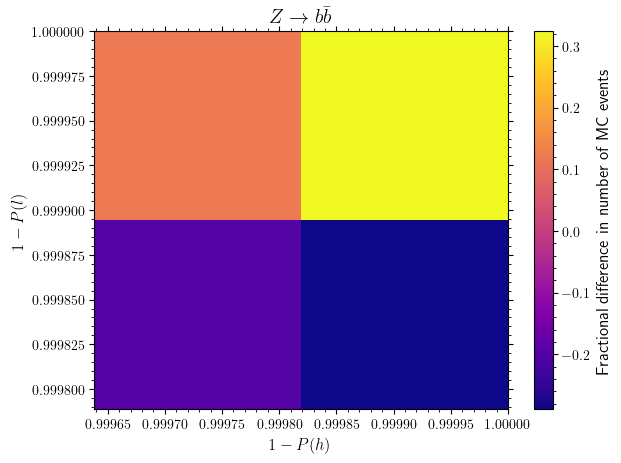

[[17.03030824 13.63563878]
 [18.33958236 15.25159286]]
[[31. 13.]
 [16. 10.]]
[[-0.45063522  0.1462239 ]
 [ 0.04889529  0.52515929]]


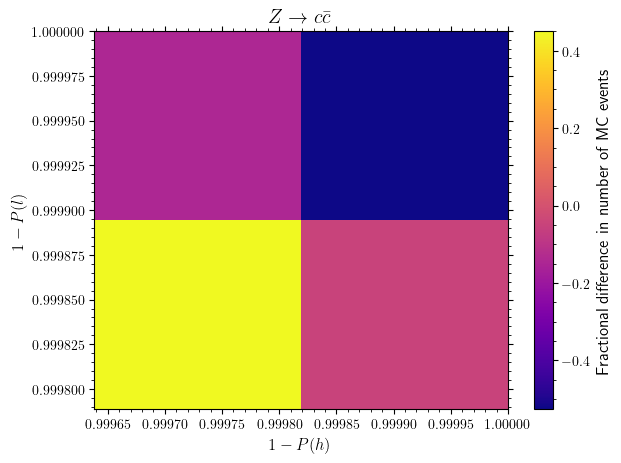

[[18.93843562 26.9718836 ]
 [18.31730087 28.48930861]]
[[15. 31.]
 [13. 34.]]
[[ 0.26256237  0.40902314]
 [-0.12993924 -0.16207916]]


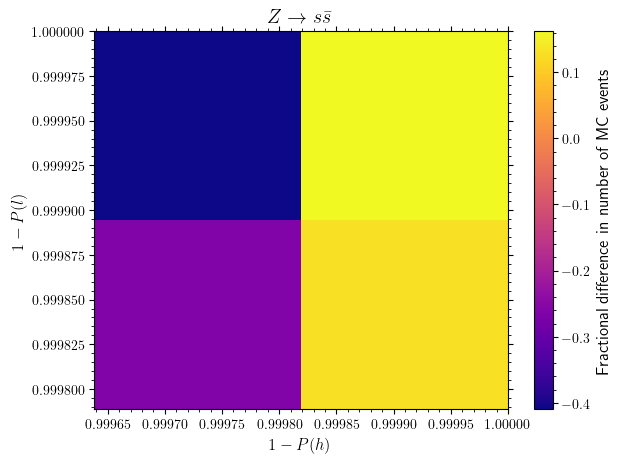

/tmp/ipykernel_2031252/3558823855.py:26: RuntimeWarning: divide by zero encountered in divide
  plt.pcolormesh(h_bins_edges, l_bins_edges, (h[0].T-N_dict_MC_0999[decay].T)/(h[0].T), shading='auto', cmap='plasma')
/tmp/ipykernel_2031252/3558823855.py:33: RuntimeWarning: divide by zero encountered in divide
  print((N_dict_MC_0999[decay]-h[0])/(h[0]))


[[2.0482595  2.98217431]
 [1.95603988 3.29995465]]
[[3. 5.]
 [0. 1.]]
[[-0.31724683         inf]
 [-0.40356514  2.29995465]]


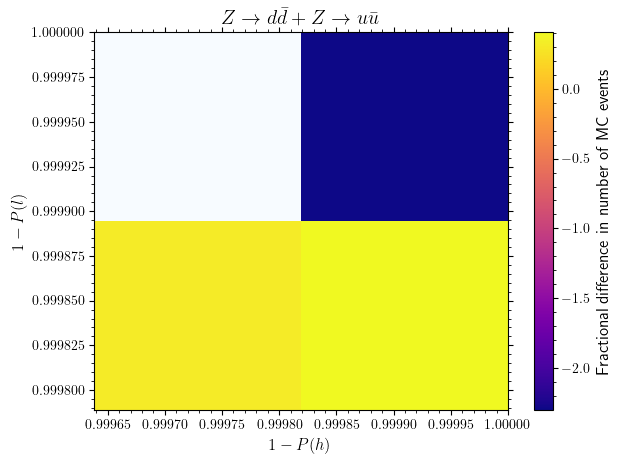

[[ 42827.93807145  45245.31767219]
 [ 51486.94895684 150102.91589135]]
[[ 42792.  45229.]
 [ 51567. 150039.]]
[[ 0.00083983 -0.00155237]
 [ 0.00036078  0.000426  ]]


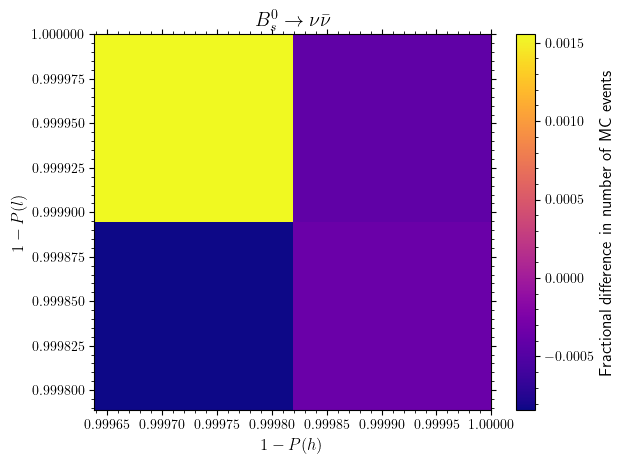

[[ 49318.92896131  54164.95744947]
 [ 60043.58196806 183553.23009498]]
[[ 49441.  54098.]
 [ 59883. 183683.]]
[[-0.00246902  0.0026816 ]
 [ 0.00123771 -0.00070649]]


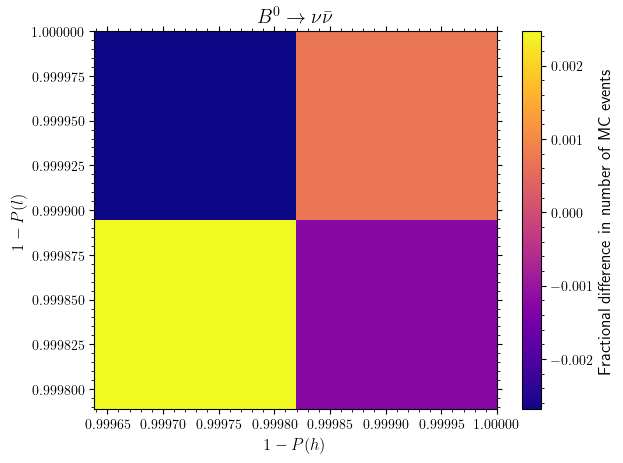

bins used
---
[0.99963819 0.9998191  1.        ]
[0.99963819 0.9998191  1.        ]
---
[0.99978894 0.99989447 1.        ]
[0.99978894 0.99989447 1.        ]
---


In [6]:
# GET HISTOGRAMS FOR DATA   
df = full_data

# find optimum cut
FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = run_2d_optimisation(interp_N_dict_0999, cut_opt_samples=cut_opt_samples, lrange_plot=lrange_interp_N_dict_0999 ,hrange_plot=hrange_interp_N_dict_0999, nlh=nlh , sig_BF=signal_BF, incl_other_syst = False)

indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]

#cut df on optimal BDT cuts
cut_data = df.copy().query(f'(P_not_light>{l_cut})&(P_not_heavy>{h_cut})')

# define samples want from components input 
samples = flatten_list([cfg.sample_allocations[component] for component in components_to_plot])

print('--> Finding number of events per bin')
# get number of events per bin in MC using np.2d histogram
#N_dict_MC={}


for decay in samples:
    
    plt.figure()
    h=plt.hist2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=histbins, cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
    plt.pcolormesh(h_bins_edges, l_bins_edges, (h[0].T-N_dict_MC_0999[decay].T)/(h[0].T), shading='auto', cmap='plasma')
    plt.colorbar(label='Fractional difference in number of MC events')
    plt.xlabel('$1-P(h)$')
    plt.ylabel('$1-P(l)$')
    plt.title(cfg.titles[decay])
    print(N_dict_MC_0999[decay].T)
    print(h[0].T)
    print((N_dict_MC_0999[decay]-h[0])/(h[0]))
    plt.show()

print("bins used")
print("---") 
print(h_bins_edges)
print(h[1])
print("---") 
print(l_bins_edges)
print(h[2])
print("---")


Note that the signal plots have changed here due to a slight change in the optimal cut sue to a change in the backgrounds!

## Creating additional mid 8x8 class

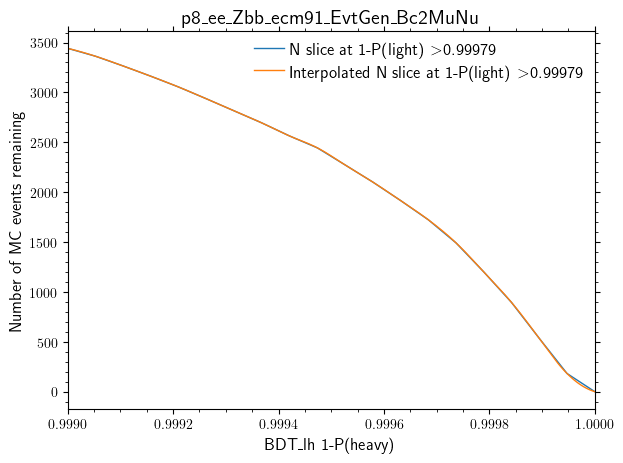

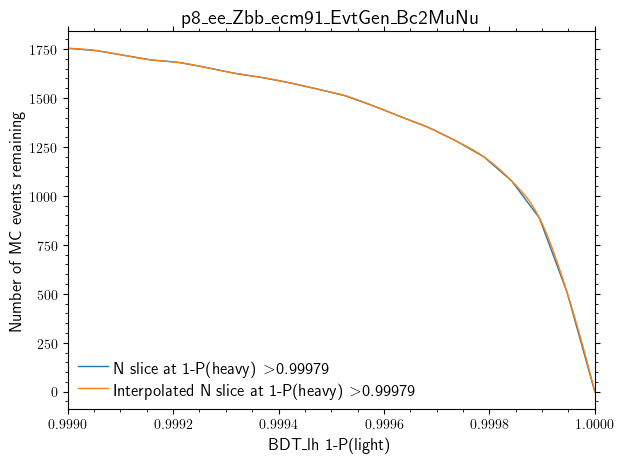

In [5]:
path_for_interpolated_dicts_0999 =  'outputs/B2lnu_backgrounds_included/BDTlh_baseline_plus_cut_optimisation/no_smoothing/0999/8x8xmidstats_4x4lowstats'

#read N interp dicts - 
with open(os.path.join(basic_functions.set_outputpath(path_for_interpolated_dicts_0999), "N_remaining_dictionary"), "rb") as dill_file:
        N_dict_0999 = dill.load(dill_file)

with open(os.path.join(basic_functions.set_outputpath(path_for_interpolated_dicts_0999), "interpolated_N_remaining_dictionary"), "rb") as dill_file:
    interp_N_dict_0999 = dill.load(dill_file)

plot_N(N_dict_0999, interp_N_dict_0999, lrange=(0.999,1) ,hrange=(0.999,1),nlh_highstats=20,nlh_midstats=8,nlh_lowstats=4,normalised=False, separate_cbar = False,slice=True, save_path='plots/exclusive_background_studies/N_interp_0999/8x8xmidstats_4x4lowstats')

In [15]:
from bdt_lh_cut_opt_significance import run_2d_optimisation, calc_SB_from_opt_cut # note that this has been updated to allow cut_opt_samples input (ie. tell it which samples to run optimisation on)
import matplotlib.pyplot as plt

samples_for_cut_opt = cfg.sample_allocations['hadronic_background'] + cfg.sample_allocations['combined_signal']
cut_opt_samples=samples_for_cut_opt 
lrange_interp_N_dict_0999=(0.999,1)
hrange_interp_N_dict_0999=(0.999,1)
nlh = 200 
signal_BF=1e-6
eventsProcessed_dict = cfg.eventsProcessed
histbins=(2,2)
components_to_plot =  ['hadronic_background','combined_signal', 'Bu2lnu_background']
binned_x_axis = np.array([['Signal depleted','Heavy background \n enriched'],['Light background \n enriched','Signal enriched']])


FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = run_2d_optimisation(interp_N_dict_0999, cut_opt_samples=cut_opt_samples, lrange_plot=lrange_interp_N_dict_0999 ,hrange_plot=hrange_interp_N_dict_0999, nlh=nlh , sig_BF=signal_BF, incl_other_syst = False)

indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]


# define samples want from components input 
samples = flatten_list([cfg.sample_allocations[component] for component in components_to_plot])


# Number of events per bin in MC from interpolation 

if histbins != (2,2):
    raise ValueError("Currently only set up for histbins=(2,2)")

else:   
    #bin edges - h on x axis, l on y axis
    h_bins_edges = np.linspace(h_cut, 1, histbins[0] + 1) #x axis
    l_bins_edges = np.linspace(l_cut, 1, histbins[1] + 1)

    
    N_dict_MC_0999 = {}

    print('--> Finding number of events per bin')
    #find number of MC events per bin after interpolation
    for sample in interp_N_dict_0999.keys():
        # Grid shape: (histbins[0]+1, histbins[1]+1)
        F = np.zeros((histbins[0] + 1, histbins[1] + 1))

        for ih in range(histbins[0] + 1):
            for il in range(histbins[1] + 1):
                F[ih, il] = interp_N_dict_0999[sample](l_bins_edges[il], h_bins_edges[ih], grid=False)
            # number of events with H > h_cut and L > l_cut
        
        
        N_MC = np.zeros((histbins[0], histbins[1]))
        
        for ih in range(histbins[0]):
            for il in range(histbins[1]):

                # finite difference
                N_MC[ih, il] = np.maximum(
                    F[ih, il]     # bottom-left corner
                    - F[ih+1, il]     # bottom-right
                    - F[ih,   il+1]   # top-left
                    + F[ih+1, il+1]   # top-right (restore overlap)
                    )

    
        N_dict_MC_0999[sample] =  N_MC

Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       157.308 |             0.999618 |             0.999563 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin


TypeError: maximum() takes from 2 to 3 positional arguments but 1 were given

Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       157.308 |             0.999618 |             0.999563 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin
[[ 37.32319649  19.43344542]
 [ 94.50189761 123.9363774 ]]
[[ 48.  20.]
 [ 86. 125.]]
[[-0.22243341  0.09885927]
 [-0.02832773 -0.00850898]]


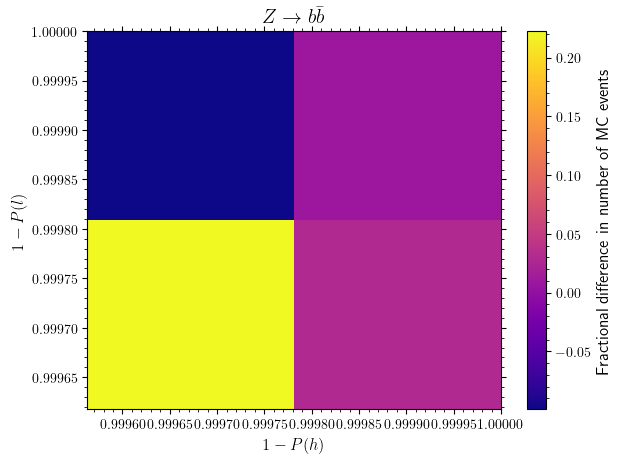

[[53.4537939  17.67934969]
 [44.52558507 27.2211615 ]]
[[46. 12.]
 [55. 27.]]
[[ 0.162039   -0.19044391]
 [ 0.47327914  0.00819117]]


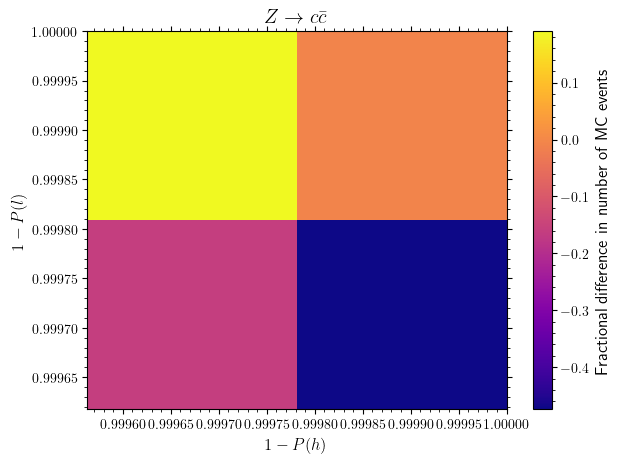

[[46.77173836 42.23347323]
 [27.54428913 68.27294307]]
[[48. 39.]
 [31. 66.]]
[[-0.02558878 -0.11147454]
 [ 0.08290957  0.03443853]]


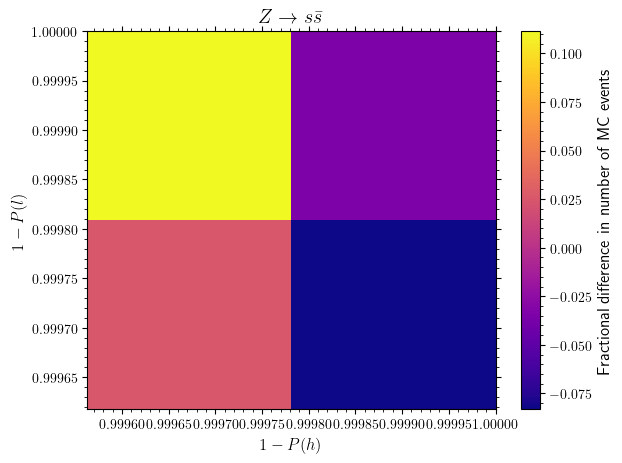

[[4.42543177 5.57750956]
 [3.55362993 6.66584245]]
[[5. 7.]
 [3. 4.]]
[[-0.11491365  0.18454331]
 [-0.20321292  0.66646061]]


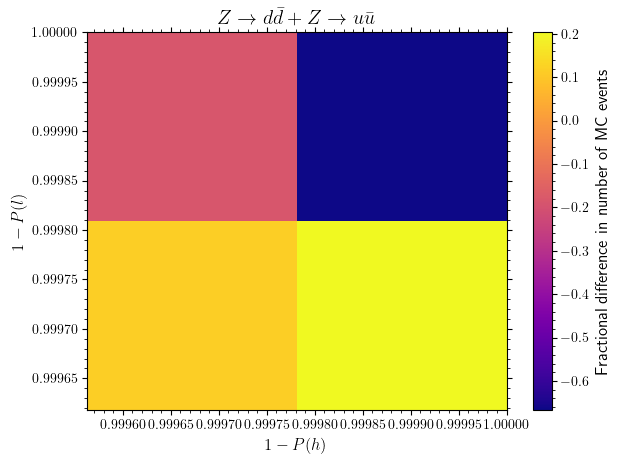

[[ 39419.61741616  38577.81339592]
 [ 82341.93251276 215986.3075683 ]]
[[ 39457.  38586.]
 [ 82276. 215953.]]
[[-0.00094743  0.00080136]
 [-0.00021217  0.00015424]]


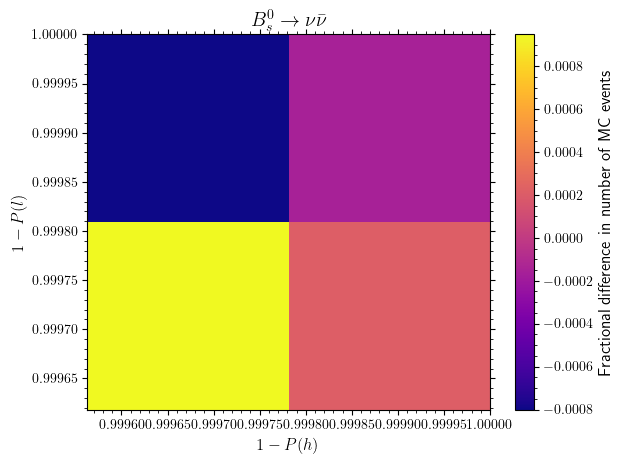

[[ 45441.59929979  45615.69061223]
 [ 94057.62826813 262063.22940782]]
[[ 45233.  45652.]
 [ 94135. 262071.]]
[[ 4.61166184e-03 -8.21923109e-04]
 [-7.95351524e-04 -2.96507137e-05]]


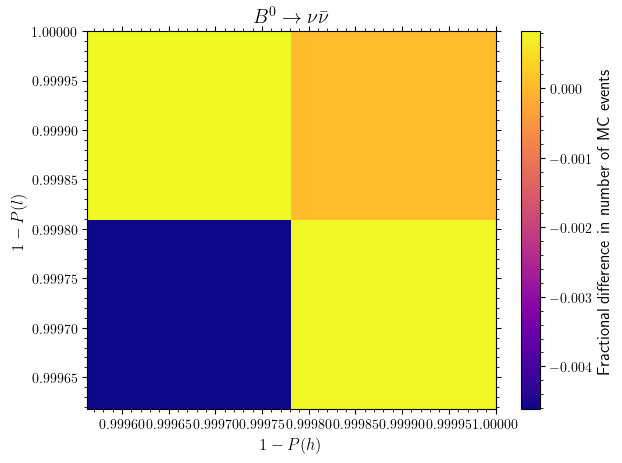

[[203.95306425 161.59395421]
 [533.38571799 921.93826767]]
[[202. 158.]
 [542. 923.]]
[[ 0.00966863 -0.01589351]
 [ 0.02274655 -0.00115031]]


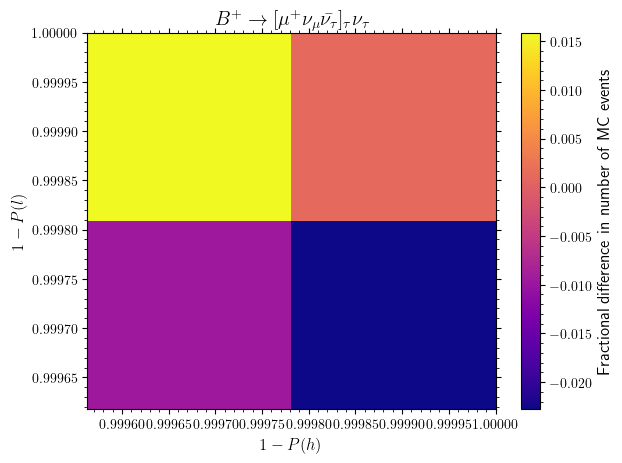

[[13.7132614  -1.29284   ]
 [69.44726426 23.53467242]]
[[12.  1.]
 [69. 23.]]
[[ 0.14277178  0.00648209]
 [-2.29284     0.02324663]]


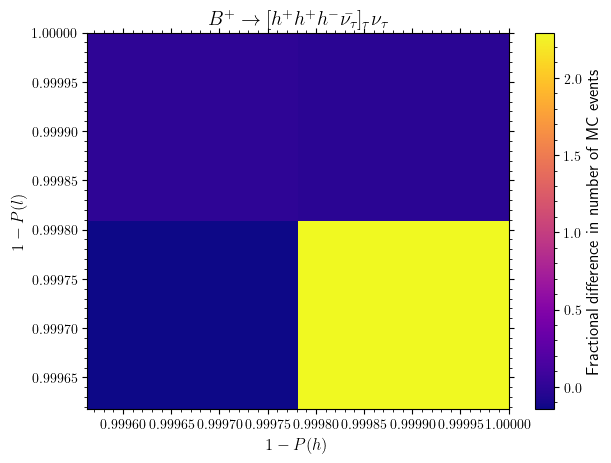

[[1819.28815748 1413.3771758 ]
 [4549.60711788 8073.48514326]]
[[1865. 1441.]
 [4511. 8063.]]
[[-0.02451037  0.00855844]
 [-0.0191692   0.0013004 ]]


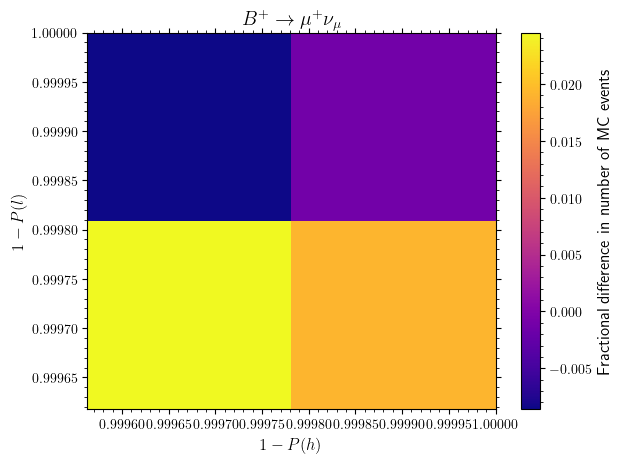

bins used
---
[0.99956281 0.99978141 1.        ]
[0.99956281 0.99978141 1.        ]
---
[0.99961809 0.99980905 1.        ]
[0.99961809 0.99980905 1.        ]
---


In [13]:
# GET HISTOGRAMS FOR DATA   
df = full_data

# find optimum cut
FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = run_2d_optimisation(interp_N_dict_0999, cut_opt_samples=cut_opt_samples, lrange_plot=lrange_interp_N_dict_0999 ,hrange_plot=hrange_interp_N_dict_0999, nlh=nlh , sig_BF=signal_BF, incl_other_syst = False)

indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]

#cut df on optimal BDT cuts
cut_data = df.copy().query(f'(P_not_light>{l_cut})&(P_not_heavy>{h_cut})')

# define samples want from components input 
samples = flatten_list([cfg.sample_allocations[component] for component in components_to_plot])

print('--> Finding number of events per bin')
# get number of events per bin in MC using np.2d histogram
#N_dict_MC={}


for decay in samples:
    
    plt.figure()
    h=plt.hist2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=histbins, cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
    plt.pcolormesh(h_bins_edges, l_bins_edges, (h[0].T-N_dict_MC_0999[decay].T)/(h[0].T), shading='auto', cmap='plasma')
    plt.colorbar(label='Fractional difference in number of MC events')
    plt.xlabel('$1-P(h)$')
    plt.ylabel('$1-P(l)$')
    plt.title(cfg.titles[decay])
    print(N_dict_MC_0999[decay].T)
    print(h[0].T)
    print((N_dict_MC_0999[decay]-h[0])/(h[0]))
    plt.show()

print("bins used")
print("---") 
print(h_bins_edges)
print(h[1])
print("---") 
print(l_bins_edges)
print(h[2])
print("---")

Calculating S and B
+---------------+----------------------+----------------------+
|   Optimal FOM |   Optimal 1-P(l) cut |   Optimal 1-P(h) cut |
+===============+======================+======================+
|       157.308 |             0.999618 |             0.999563 |
+---------------+----------------------+----------------------+
--> Finding number of events per bin
[[ 37.32319649  19.43344542]
 [ 94.50189761 123.9363774 ]]
[[ 48.  20.]
 [ 86. 125.]]
[[-10.67680351   8.50189761]
 [ -0.56655458  -1.0636226 ]]


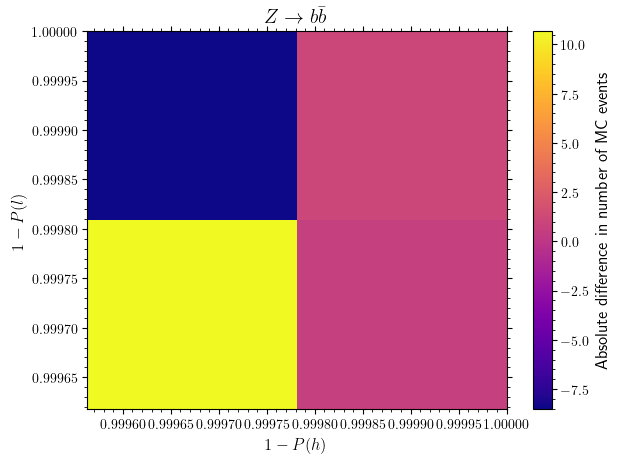

[[53.4537939  17.67934969]
 [44.52558507 27.2211615 ]]
[[46. 12.]
 [55. 27.]]
[[  7.4537939  -10.47441493]
 [  5.67934969   0.2211615 ]]


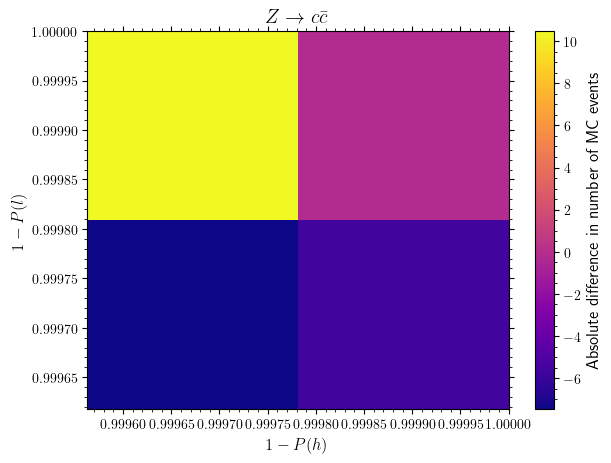

[[46.77173836 42.23347323]
 [27.54428913 68.27294307]]
[[48. 39.]
 [31. 66.]]
[[-1.22826164 -3.45571087]
 [ 3.23347323  2.27294307]]


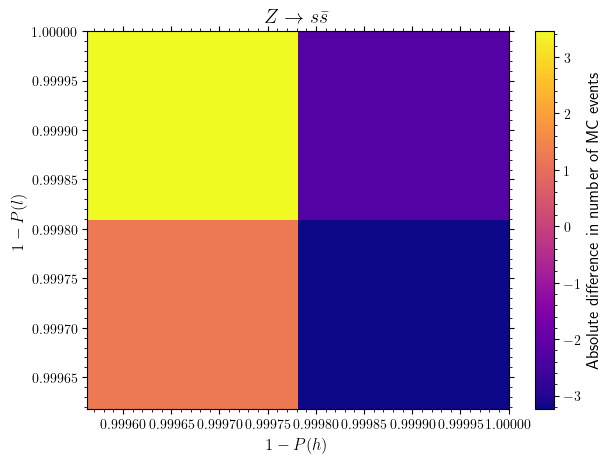

[[4.42543177 5.57750956]
 [3.55362993 6.66584245]]
[[5. 7.]
 [3. 4.]]
[[-0.57456823  0.55362993]
 [-1.42249044  2.66584245]]


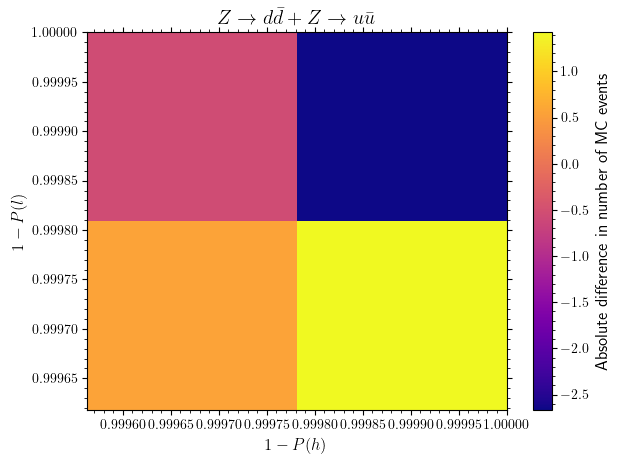

[[ 39419.61741616  38577.81339592]
 [ 82341.93251276 215986.3075683 ]]
[[ 39457.  38586.]
 [ 82276. 215953.]]
[[-37.38258384  65.93251276]
 [ -8.18660408  33.3075683 ]]


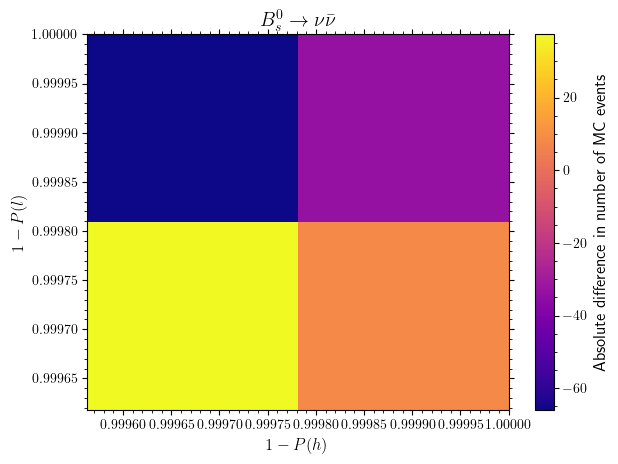

[[ 45441.59929979  45615.69061223]
 [ 94057.62826813 262063.22940782]]
[[ 45233.  45652.]
 [ 94135. 262071.]]
[[208.59929979 -77.37173187]
 [-36.30938777  -7.77059218]]


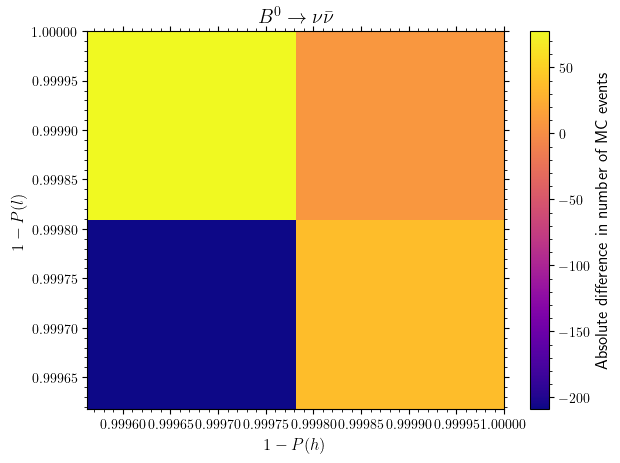

[[203.95306425 161.59395421]
 [533.38571799 921.93826767]]
[[202. 158.]
 [542. 923.]]
[[ 1.95306425 -8.61428201]
 [ 3.59395421 -1.06173233]]


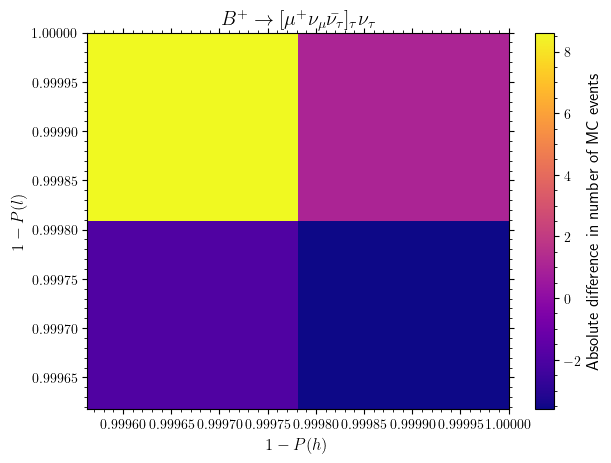

[[13.7132614  -1.29284   ]
 [69.44726426 23.53467242]]
[[12.  1.]
 [69. 23.]]
[[ 1.7132614   0.44726426]
 [-2.29284     0.53467242]]


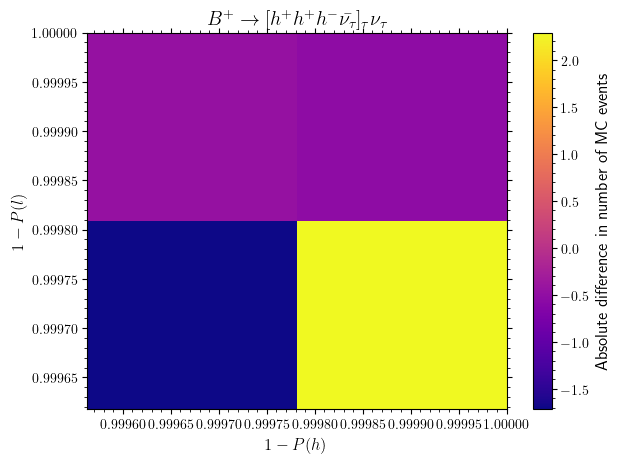

[[1819.28815748 1413.3771758 ]
 [4549.60711788 8073.48514326]]
[[1865. 1441.]
 [4511. 8063.]]
[[-45.71184252  38.60711788]
 [-27.6228242   10.48514326]]


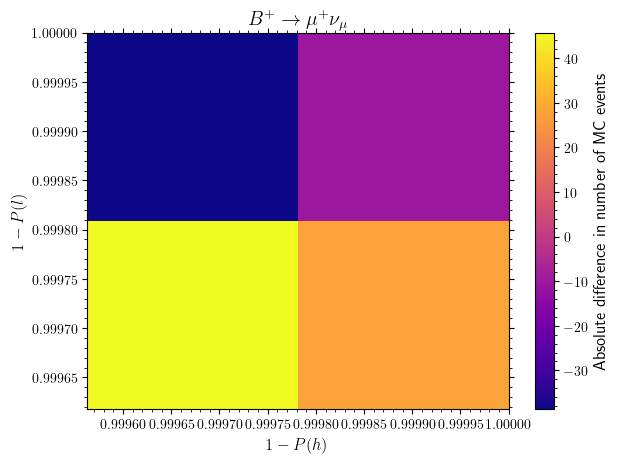

bins used
---
[0.99956281 0.99978141 1.        ]
[0.99956281 0.99978141 1.        ]
---
[0.99961809 0.99980905 1.        ]
[0.99961809 0.99980905 1.        ]
---


In [14]:
# GET HISTOGRAMS FOR DATA   
df = full_data

# find optimum cut
FOM, err_FOM, S_arr, B_arr, S_error_arr, B_error_arr, lsearch, hsearch, sig_BF, = run_2d_optimisation(interp_N_dict_0999, cut_opt_samples=cut_opt_samples, lrange_plot=lrange_interp_N_dict_0999 ,hrange_plot=hrange_interp_N_dict_0999, nlh=nlh , sig_BF=signal_BF, incl_other_syst = False)

indices = np.unravel_index(np.argmax(FOM), np.shape(FOM))
l_cut = lsearch[indices[0]]
h_cut = hsearch[indices[1]]

#cut df on optimal BDT cuts
cut_data = df.copy().query(f'(P_not_light>{l_cut})&(P_not_heavy>{h_cut})')

# define samples want from components input 
samples = flatten_list([cfg.sample_allocations[component] for component in components_to_plot])

print('--> Finding number of events per bin')
# get number of events per bin in MC using np.2d histogram
#N_dict_MC={}


for decay in samples:
    
    plt.figure()
    h=plt.hist2d(cut_data[cut_data['decay']==decay]["P_not_heavy"], cut_data[cut_data['decay']==decay]["P_not_light"], bins=histbins, cmap=plt.cm.Blues,vmin=0,density=False,range = [[h_cut, 1], [l_cut, 1]])
    plt.pcolormesh(h_bins_edges, l_bins_edges, (h[0].T-N_dict_MC_0999[decay].T), shading='auto', cmap='plasma')
    plt.colorbar(label='Absolute difference in number of MC events')
    plt.xlabel('$1-P(h)$')
    plt.ylabel('$1-P(l)$')
    plt.title(cfg.titles[decay])
    print(N_dict_MC_0999[decay].T)
    print(h[0].T)
    print((N_dict_MC_0999[decay]-h[0]))
    plt.show()

print("bins used")
print("---") 
print(h_bins_edges)
print(h[1])
print("---") 
print(l_bins_edges)
print(h[2])
print("---")